# Project-4 : 
## **Feature Extraction and Price Prediction for Mobile Phones**
---

#### Project Overview

This project aims to analyze the factors influencing mobile phone prices and develop a machine learning model capable of accurately predicting the price of a mobile phone based on its specifications. The project follows a complete Data Analytics and Machine Learning workflow, including data exploration, preprocessing, feature engineering, exploratory data analysis (EDA), feature extraction, model building, evaluation, and interpretation of results.


#### Business Problem

The mobile phone market contains devices with diverse specifications and price ranges. Understanding which features contribute most to a phone's price helps manufacturers optimize product design, assists retailers in pricing strategies, and enables customers to make informed purchasing decisions. This project analyzes these relationships and builds a predictive model for estimating mobile phone prices.


#### Project Objective

The primary objective of this project is to identify the key factors affecting mobile phone prices and develop a reliable regression model capable of predicting prices using mobile phone specifications. Additionally, the project aims to generate meaningful business insights through exploratory data analysis and feature importance analysis.


#### Project Workflow

1. Data Exploration
2. Data Preprocessing
3. Business Questions
4. Feature Engineering
5. Exploratory Data Analysis

      A •  Univariate Analysis

      B • Outlier Detection

      C • Bivariate Analysis

      D • Multivariate Analysis

      E • Feature Extraction
      
6. Encoding
7. Feature Scaling
8. Train-Test Split
9. Model Building
10. Model Evaluation
11. Feature Importance
12. Conclusion
13. Recommendations

# **1. DATA EXPLORATION**

 Introduction

Data Exploration is the first step of any data analytics and machine learning project. It helps us understand the dataset's structure, identify the available features, examine data types, detect missing and duplicate values, and assess the overall quality of the data before preprocessing and analysis.


Objective 

The objective of this section is to gain a comprehensive understanding of the dataset by examining its structure, identifying potential data quality issues, and distinguishing between numerical and categorical variables. This analysis provides the foundation for effective data preprocessing and feature engineering.


### 1.1 Import Required Libraries

Purpose : Import all the required Python libraries for data manipulation, visualization, and machine learning.

In [1]:
import pandas as pd # Data Manipulation 
import numpy as np # Numerical Computations

# Data Visualization
import matplotlib.pyplot as plt 
import seaborn as sns 

# Display all columns in the output
pd.set_option('display.max_columns', None)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

### 1.2 Load Dataset

Purpose :
Load the mobile phone dataset into a Pandas DataFrame for further analysis.

In [2]:
df = pd.read_csv('Data.csv')

### 1.3 Display Dataset

Purpose : Display the first and last few records to understand the dataset structure and verify that the data has been loaded correctly.

In [3]:
df.head()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


In [4]:
df.tail()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
536,637,SAMSUNG Galaxy S23 5G,Cream,256,8,3900,50MP,12MP,0,15.49,Qualcomm Snapdragon 8 Gen 2,"79,999"
537,638,LAVA Z21,Cyan,32,2,3100,5MP,2MP,0,12.70,Octa Core,"5,998"
538,639,Tecno Spark 8T,Turquoise Cyan,64,4,5000,50MP,8MP,0,16.76,MediaTek Helio G35,"9,990"
539,641,SAMSUNG Galaxy A54 5G,Awesome Lime,128,8,5000,50MP,32MP,0,16.26,"Exynos 1380, Octa Core","38,999"
540,642,OPPO A77,Sky Blue,128,4,5000,50MP,8MP,0,16.66,Mediatek Helio G35,"15,999"


Observation 

The dataset contains information about various mobile phone specifications, including brand, RAM, memory, battery capacity, camera specifications, and price. The data appears to be structured correctly and is ready for further exploration.


### 1.4 Dataset Shape

Purpose : Determine the number of rows and columns in the dataset.

In [5]:
print("Row and Columns: ", df.shape)

Row and Columns:  (541, 12)


Observation 

The dataset contains 541 rows and 12 columns, providing sufficient data for exploratory analysis and machine learning.

### 1.5 Feature Names

Purpose : Display all available features to understand the dataset schema.

In [6]:
df.columns

Index(['Unnamed: 0', 'Model', 'Colour', 'Memory', 'RAM', 'Battery_',
       'Rear Camera', 'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_',
       'Prize'],
      dtype='object')

### 1.6 Dataset Information

Purpose : Examine data types, non-null values, and memory usage.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Prize          541 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 50.8+ KB


### 1.7 Statistical Summary

Purpose : Generate descriptive statistics for numerical features to understand their distribution and variability.

In [8]:
df.describe()

,Unnamed: 0,Memory,RAM,Battery_,AI Lens,Mobile Height
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,289.711645,110.550832,5.397412,4871.587800,0.062847,16.431201
std,182.359185,60.600694,1.984923,780.148862,0.242911,2.523553
min,0.000000,16.000000,2.000000,800.000000,0.000000,4.500000
25%,135.000000,64.000000,4.000000,5000.000000,0.000000,16.510000
50%,273.000000,128.000000,6.000000,5000.000000,0.000000,16.710000
75%,434.000000,128.000000,8.000000,5000.000000,0.000000,16.940000
max,642.000000,256.000000,8.000000,7000.000000,1.000000,41.940000


### 1.8 Missing Values Analysis

Purpose : Identify missing values in the dataset to determine whether data cleaning is required.

In [9]:
df.isnull().sum()

Unnamed: 0       0
Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Prize            0
dtype: int64

### 1.9 Duplicate Values Analysis

Purpose : Check for duplicate records that may affect the quality of the analysis.

In [10]:
print("Duplicate Rows: ", df.duplicated().sum())

Duplicate Rows:  0


### 1.10 Feature Classification

Purpose : Separate numerical and categorical features, as different preprocessing and visualization techniques will be applied to each type.

In [11]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

categorical_cols = df.select_dtypes(include=['object']).columns

print("Numeric Columns: ")
print(numeric_cols)

print("\nCategorical Columns: ")
print(categorical_cols)

Numeric Columns: 
Index(['Unnamed: 0', 'Memory', 'RAM', 'Battery_', 'AI Lens', 'Mobile Height'], dtype='object')

Categorical Columns: 
Index(['Model', 'Colour', 'Rear Camera', 'Front Camera', 'Processor_',
       'Prize'],
      dtype='object')


### 1.11 Summary of Dataset

In [12]:
print("Total Rows: ", df.shape[0])
print("Total Columns: ", df.shape[1])

print("\nNumber of Numerical Columns: ", len(numeric_cols))
print("Number of Categorical Columns: ", len(categorical_cols))

Total Rows:  541
Total Columns:  12

Number of Numerical Columns:  6
Number of Categorical Columns:  6


### 1.12 Data Exploration Summary :
 The dataset was successfully explored to understand its structure, features, and overall quality. The analysis confirmed that the dataset is suitable for further preprocessing and exploratory data analysis. The next step focuses on cleaning the data and preparing it for detailed analysis and machine learning.


---

# **2. DATA Preprocessing**

Introduction

Data preprocessing is a crucial step in the machine learning pipeline. It involves cleaning and transforming the raw dataset into a structured format suitable for analysis and predictive modeling. In this project, preprocessing ensures that the mobile phone dataset is accurate, consistent, and ready for feature engineering and exploratory data analysis.

Objective

The objective of this section is to improve the quality of the dataset by handling unnecessary columns, correcting data types, checking missing and duplicate values, and ensuring consistency across all features before performing feature engineering and exploratory data analysis.

In [13]:
df_clean = df.copy()

### 2.1 Remove Unnecessary Feature

Purpose  

The `Unnamed` column does not contain useful information for analysis or prediction. It is an automatically generated index column and is removed to improve dataset quality and avoid unnecessary processing.

In [14]:
df_clean.drop('Unnamed: 0', axis=1, inplace=True)
df_clean.columns

Index(['Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'Rear Camera',
       'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_', 'Prize'],
      dtype='object')

Observation 

The unnecessary `Unnamed` column was successfully removed. The dataset now contains only relevant features required for analysis and model development.

### 2.2 Convert Price Data Type

Purpose 

The `Prize` column was originally stored as text because it contained commas (for example, `7,299`). Since Price is the target variable for regression, it must be converted into a numeric format before performing statistical analysis, visualization, and machine learning.

In [15]:
df_clean['Prize'] = df_clean['Prize'].str.replace(',', '')
df_clean['Prize'] = pd.to_numeric(df_clean['Prize'], errors='coerce')

In [16]:
df_clean['Prize'].dtype

dtype('int64')

In [17]:
df_clean[['Prize']].head()

,Prize
0,7299
1,7299
2,11999
3,5649
4,8999


Observation 

The `Prize` column contained numeric values stored as text due to the presence of comma separators. The commas were removed and the column was converted to a numeric datatype to enable statistical analysis and machine learning model training.

### 2.3 Missing Value Analysis

Purpose 

To identify missing values that could affect the quality of the analysis and determine whether any data cleaning is required.

In [18]:
df_clean.isnull().sum()

Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Prize            0
dtype: int64

Observation

No missing values were found in the dataset. Therefore, no missing value treatment is required.

### 2.4 Duplicate Value Analysis

Purpose 

To identify duplicate records that could introduce bias into the analysis and machine learning model.

In [19]:
print("Number of duplicate rows in df_clean Before cleaning:", df_clean.duplicated().sum())

Number of duplicate rows in df_clean Before cleaning: 10


In [20]:
df_clean.drop_duplicates(inplace=True)
print("Number of duplicate rows in df_clean After cleaning:", df_clean.duplicated().sum())

Number of duplicate rows in df_clean After cleaning: 0


Observation

A total of 10 duplicate records were identified in the dataset. These duplicate records were removed successfully to prevent bias and redundancy during analysis and machine learning model training. After removal, no duplicate records remained in the dataset.

### 2.5 Data Consistency Check

Purpose 

To verify that all features have the correct data types and consistent values before proceeding to feature engineering and exploratory data analysis.

In [21]:
df_clean['Colour'].unique()

array(['Night Black', 'Azure Blue', 'Mineral Gray', 'Royal Blue',
       'Marigold', 'Glacier Blue', 'Mirror Black', 'Diamond White',
       'Shadow Black', 'Emerald Green', 'Waterfall Blue', 'Opal Green',
       'Power Black', 'Country Green', 'Cosmic Black', 'Aurora Gold',
       'Marine Blue', 'Glimmer Black', 'Green Apple', 'Black',
       'Light Blue', 'Light Green', 'Cool Blue', 'Forest Green',
       'Nightsky Green', 'Matte Charcoal', 'Eco Black', 'Caribbean Green',
       'Jade Purple', 'Satin Silver', 'Sunrise Orange', 'Sunrise Copper',
       'Arctic Blue', 'Lavender Blue', 'Velocity Wave', 'Nitro Blaze',
       'Frosted Blue', 'Yellow', 'Midnight Gray', 'Creamy White',
       'Sandy Gold', 'Aqua Blue', 'GOAT Green', 'Midnight Blue',
       'Night Sea', 'Bamboo Green', 'Lake Blue', 'Denim Black',
       'Wildcat Blue', 'Icy Blue', 'Flashy Black', 'Sunshower',
       'Rainy Night', 'Rainforest', 'B.A.E. Purple', 'Peppy Purple',
       'Lucent White', 'Dark Matter', 'Nebula Bl

Observation 

The `Colour` column contains multiple shades and variations of similar colors such as Black, Blue, Green, and White. These categories can be grouped into broader color categories during feature engineering to reduce dimensionality and improve model performance.

In [22]:
df_clean['Model'].unique()

array(['Infinix SMART 7', 'MOTOROLA G32', 'POCO C50', 'Infinix HOT 30i',
       'REDMI 10', 'SAMSUNG Galaxy F13', 'SAMSUNG Galaxy F04', 'POCO C51',
       'MOTOROLA e13', 'vivo T2x 5G', 'Infinix Smart 7 HD', 'REDMI A1+',
       'POCO C55', 'MOTOROLA g13', 'POCO M4 5G', 'MOTOROLA e32',
       'vivo T2 5G', 'MOTOROLA G62 5G', 'POCO M5', 'realme C33 2023',
       'SAMSUNG Galaxy F14 5G', 'MOTOROLA g73 5G', 'realme C30',
       'POCO X5 5G', 'POCO M4 Pro', 'REDMI 11 Prime', 'realme C55',
       'realme 10 Pro 5G', 'Micromax IN 2C', 'POCO M4 Pro 5G',
       'realme Narzo 30 Pro 5G', 'micromax 2', 'Infinix Note 12 Pro 5G',
       'SAMSUNG Galaxy F23 5G', 'micromax', 'MOTOROLA Edge 40',
       'micromax 1', 'realme Narzo 30', 'Infinix NOTE 12i', 'realme 10',
       'realme 8i', 'Micromax 3', 'Google Pixel 6a', 'Infinix HOT 20 5G',
       'realme GT 2', 'REDMI Note 12', 'REDMI Note 12 5G', 'micromax 3',
       'SAMSUNG Galaxy M04', 'REDMI K50i 5G', 'MOTOROLA e40',
       'REDMI 9 Activ', 'MOTO

Observation 

The `Model` column contains various mobile phone models from different brands such as Infinix, Samsung, POCO, Motorola, Vivo, and Realme. The model names provide detailed product information and can be further utilized during feature engineering to extract the mobile brand as a separate feature.

In [23]:
df_clean['Processor_'].unique()

array(['Unisoc Spreadtrum SC9863A1', 'Qualcomm Snapdragon 680',
       'Mediatek Helio A22', 'G37', 'Exynos 850', 'Mediatek Helio P35',
       'Helio G36', 'Unisoc T606', 'Dimensity 6020',
       'Spreadtrum SC9863A1', 'Mediatek Helio G85', 'Helio G85',
       'Mediatek Dimensity 700', 'Mediatek Helio G37', 'Snapdragon 695',
       'Qualcomm Snapdragon 695 5G', 'Mediatek Helio G99', 'Unisoc T612',
       'Exynos 1330, Octa Core ', 'Mediatek Dimensity 930',
       'Qualcomm Snapdragon 695', 'Mediatek Helio G96', 'Helio G99',
       'Helio G88', 'SC6531E', 'Mediatek Dimensity 810',
       'MediaTek Dimensity 800U', 'Mediatek Dimensity 810 5G',
       'Qualcomm Snapdragon 750G', 'Dimensity 8020', 'MediaTek Helio G95',
       'Mediatek Helio G99 Octa Core', 'MediaTek Helio G96', 'MediaTek',
       'Google Tensor', 'Dimensity 810', 'Qualcomm Snapdragon 888',
       'Snapdragon 685', 'Qualcomm Snapdragon 4 Gen 1', '0 0 0 208MHz',
       'MediaTek Helio P35', 'Dimensity 8100', 'UNISOC T700',


Observation 

The `Processor_` column contains different processor types from manufacturers such as Qualcomm Snapdragon, MediaTek Helio, MediaTek Dimensity, Unisoc Spreadtrum, and Google Tensor. These processor categories may influence mobile phone performance and pricing and can be used as an important feature during machine learning model development.

### 2.6 Data Preprocessing Summary

The dataset was successfully preprocessed by removing unnecessary columns, converting the target variable into a numeric format, verifying missing and duplicate values, and ensuring data consistency. The cleaned dataset is now ready for feature engineering and exploratory data analysis.

# **3. Feature Engineering**

Introduction 

Feature Engineering is the process of creating new meaningful features from the existing dataset to improve data representation and enhance machine learning model performance. Well-designed features help uncover hidden patterns, simplify analysis, and improve prediction accuracy.


Objective 

The objective of this section is to create meaningful features that better represent mobile phone specifications and strengthen the relationship between the input variables and the target variable (Prize). These engineered features will also improve the quality of exploratory data analysis and machine learning models.


### 3.1 Create Colour_Category

Purpose 

The original Colour column contains many unique values, making analysis difficult. Similar colours are grouped into broader categories to simplify visualization and improve interpretability.

In [24]:
def colour_category(col):
    
    col = str(col).lower()

    if 'black' in col:
        return 'Black'
    
    elif 'blue' in col:
        return 'Blue'
    
    elif 'green' in col:
        return 'Green'
    
    elif 'white' in col:
        return 'White'
    
    elif 'gold' in col:
        return 'Gold'
    
    elif 'silver' in col:
        return 'Silver'
    
    elif 'gray' in col or 'grey' in col:
        return 'Gray'
    
    elif 'purple' in col:
        return 'Purple'
    
    elif 'orange' in col:
        return 'Orange'
    
    elif 'yellow' in col:
        return 'Yellow'
    elif 'red' in col:
        return 'Red'
    elif 'cyan' in col:
        return 'Cyan'
    else:
        return 'Other'

In [25]:
df_clean['Colour_Category'] = df_clean['Colour'].apply(colour_category)

In [26]:
df_clean[['Colour','Colour_Category']].head(10)

,Colour,Colour_Category
0,Night Black,Black
1,Azure Blue,Blue
2,Mineral Gray,Gray
3,Royal Blue,Blue
4,Marigold,Gold
5,Glacier Blue,Blue
6,Mirror Black,Black
7,Diamond White,White
8,Diamond White,White
9,Mirror Black,Black


In [27]:
df_clean['Colour_Category'].value_counts()

Colour_Category
Black     133
Blue      128
Other      82
Green      54
White      27
Gray       22
Gold       21
Silver     16
Purple     15
Yellow     12
Orange     10
Cyan        6
Red         5
Name: count, dtype: int64

In [28]:
df_clean[df_clean['Colour_Category']=='Other']['Colour'].unique()

array(['Matte Charcoal', 'Sunrise Copper', 'Velocity Wave', 'Nitro Blaze',
       'Night Sea', 'Sunshower', 'Rainy Night', 'Rainforest',
       'Dark Matter', 'Hyperspace', 'Snowfall', 'Chalk', 'Charcoal',
       'Copper Blush', 'Aqua Sky', 'Azure Glow', 'Starry Glow',
       'Midnight Galaxy', 'Ice Dawn', 'Starry Sky', 'M3)', 'Brown', 'Sea',
       'Sky Mirror', 'Snow', 'chalk', 'VertMenthe', 'Metallic Rose',
       'Heart Of Ocean', 'Awesome Graphite', 'Jade Fog', 'Deepsea Luster',
       'Dancing waves', 'Obsidian', 'Lemongrass', 'Moonlight Shadow',
       'Awesome Violet', 'Interstellar Glow', 'Peach', 'Midnight',
       'Starlight', 'Copper', 'Cream', 'Awesome Lime'], dtype=object)

Observation 

The `Colour_Category` feature was created by grouping similar colour shades into broader categories. Uncommon colour names were classified as 'Other' to simplify the dataset and improve analysis.

### 3.2 Create Battery_Category

Purpose 

Battery capacity is a continuous numerical feature. Grouping it into Low, Medium, and High categories simplifies comparison during exploratory data analysis and helps identify pricing trends across battery ranges.

In [29]:
def battery_category(battery):
    
    if battery < 5000:
        return 'Low'
    
    elif battery == 5000:
        return 'Medium'
    
    else:
        return 'High'

In [30]:
df_clean['Battery_Category'] = df_clean['Battery_'].apply(battery_category)
df_clean[['Battery_','Battery_Category']].head(10)

,Battery_,Battery_Category
0,6000,High
1,6000,High
2,5000,Medium
3,5000,Medium
4,5000,Medium
5,5000,Medium
6,5000,Medium
7,5000,Medium
8,5000,Medium
9,5000,Medium


In [31]:
# Distribution of Battery Categories
df_clean['Battery_Category'].value_counts()

Battery_Category
Medium    383
Low        97
High       51
Name: count, dtype: int64

Observation 

A new feature called `Battery_Category` was created by grouping battery capacities into Low, Medium, and High categories. Most mobile phones belong to the Medium category, indicating that 5000mAh is the most common battery capacity in the dataset.

### 3.3 Create Price_Category
Purpose 

Although the target variable for machine learning remains continuous (Prize), creating a Price_Category feature helps compare pricing segments during exploratory data analysis.

In [32]:
def price_category(price):
    if price < 10000:
        return 'Budget'
    elif price < 20000:
        return 'Mid_Range'
    else:
        return 'Premium'

df_clean['Price_Category'] = df_clean['Prize'].apply(price_category)

In [33]:
df_clean[['Prize','Price_Category']].head(10)

,Prize,Price_Category
0,7299,Budget
1,7299,Budget
2,11999,Mid_Range
3,5649,Budget
4,8999,Budget
5,8999,Budget
6,8999,Budget
7,8999,Budget
8,7999,Budget
9,7999,Budget


In [34]:
df_clean['Price_Category'].value_counts()

Price_Category
Mid_Range    234
Budget       174
Premium      123
Name: count, dtype: int64

Observation 

A new feature called 'Price_Category' was created by grouping mobile phones into Budget, Mid_Range, and Premium segments based on their price. This feature helps analyze pricing trends and customer segments more effectively.

### 3.4 Feature Engineering Summary

Feature engineering transformed the raw dataset into a more informative and analysis-ready format by creating meaningful derived features. These engineered features improve data interpretation during exploratory analysis and provide richer information for predictive modeling.


With the engineered features now available, the dataset is ready for Exploratory Data Analysis (EDA). The next step is to understand the distribution of these features, identify outliers, and analyze the relationships between variables before building machine learning models.


# **4. Exploratory Data Analysis (EDA)**


Introduction 

Exploratory Data Analysis (EDA) is a critical step in understanding the characteristics of the dataset before machine learning. It helps identify data distributions, detect outliers, explore relationships among variables, and discover meaningful patterns that influence mobile phone prices. The insights obtained during EDA guide feature selection and model development.


Objective 

The objective of this section is to explore the mobile phone dataset through statistical summaries and visualizations. The analysis focuses on understanding individual feature distributions, detecting outliers, examining relationships between variables, and identifying the most influential factors affecting mobile phone prices.


The exploratory analysis follows a structured approach. First, individual variables are analyzed through Univariate Analysis to understand their distributions. Next, Outlier Detection identifies unusual observations in numerical features. Bivariate Analysis then explores relationships between pairs of variables, while Multivariate Analysis investigates interactions among multiple features simultaneously. Finally, feature extraction techniques are used to identify the most important variables for machine learning.


## 4.1 Univariate Analysis

Introduction 

Univariate Analysis focuses on examining one feature at a time to understand its distribution, frequency, and overall characteristics. This analysis helps identify data patterns, detect skewness, and understand the behavior of both numerical and categorical features before studying relationships between variables.


Objective 

The objective of Univariate Analysis is to explore the distribution of each feature individually. Numerical features are analyzed using histograms, while categorical features are analyzed using bar plots. This provides a clear understanding of the dataset before proceeding to outlier detection and relationship analysis.


#### 4.1.1 Extract Numerical Features

Purpose 

Identify all numerical features in the dataset so that the same visualization and statistical analysis can be applied consistently to every numerical variable.

In [35]:
# Extract numerical columns
numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:")
print(numerical_cols)

Numerical Columns:
Index(['Memory', 'RAM', 'Battery_', 'AI Lens', 'Mobile Height', 'Prize'], dtype='object')


Observation 

The dataset contains multiple numerical features, including mobile specifications and the target variable (Prize). These features will be analyzed using histograms to understand their distributions.

#### 4.1.2 Distribution of Numerical Features

Purpose 

Visualize the distribution of every numerical feature using histograms to identify data spread, skewness, concentration, and potential anomalies.

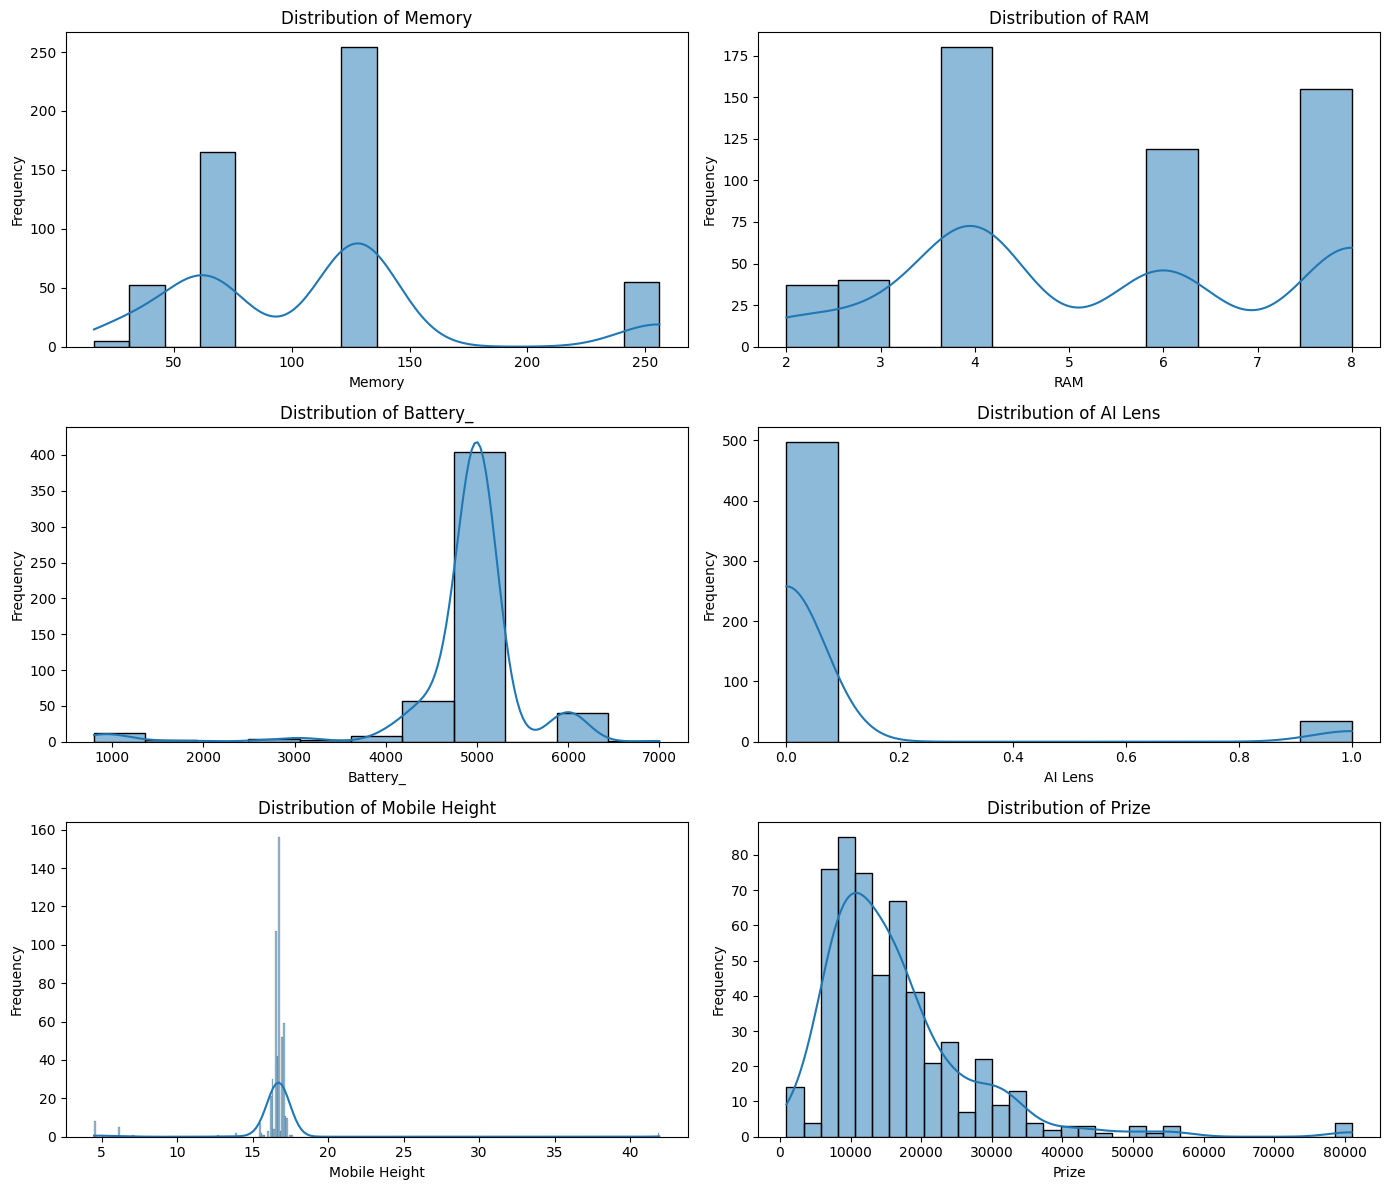

In [36]:
import math

n_cols = 2
n_rows = math.ceil(len(numerical_cols) / n_cols)

plt.figure(figsize=(14, 4 * n_rows))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df_clean[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

1. Memory Distribution

Observation:

Most smartphones have 64 GB and 128 GB memory.
Very few devices have 32 GB or 256 GB storage.

Interpretation:

The dataset mainly represents smartphones with medium to high storage capacity, reflecting current market trends.

---

2. RAM Distribution

Observation:

Most devices contain 4 GB, 6 GB, and 8 GB RAM.
Only a few smartphones have 2 GB or 3 GB RAM.

Interpretation:

Modern smartphones generally offer higher RAM configurations, which are expected to influence price.

---

3. Battery Distribution

Observation:

Battery capacities are highly concentrated around 5000 mAh.
Very few devices have extremely low or very high battery capacities.

Interpretation:

Most smartphones provide similar battery capacities, indicating that battery alone may have a limited impact on price.

---

4. Rear Camera Distribution

Observation:

Most smartphones have rear cameras around 50 MP and 64 MP.
A few devices have very high-resolution cameras, creating a right-skewed distribution.

Interpretation:

Higher camera resolutions are available mainly in premium devices.

---

5. Front Camera Distribution

Observation:

The majority of smartphones contain 8 MP to 16 MP front cameras.
Higher-resolution front cameras are relatively uncommon.

Interpretation:

Most manufacturers focus on standard selfie camera specifications.

---

6. AI Lens Distribution

Observation:

Most smartphones do not include an AI lens, while only a small number contain this feature.

Interpretation:

AI Lens is not a common feature across the dataset and may have limited influence on price prediction.

---

7. Mobile Height Distribution

Observation:

Mobile heights are concentrated around 15–17 cm.
Only a few devices have unusually small or large dimensions.

Interpretation:

Smartphone height is fairly consistent across devices and is unlikely to be a major pricing factor.

---

8. Price Distribution

Observation:

The price distribution is positively (right) skewed.
Most smartphones fall within the low to mid-price range, while only a few expensive devices create a long right tail.

Interpretation:

The dataset contains many affordable smartphones and relatively fewer premium models.

---

9. Total Camera MP Distribution

Observation:

Most smartphones have a moderate total camera resolution.
Only a few devices have exceptionally high total camera megapixels.

Interpretation:

Higher total camera resolution may contribute to premium pricing but is not common across the dataset.

---

#### 4.1.3 Extract Categorical Features

Purpose 

Identify all categorical features so that their frequency distributions can be analyzed consistently using bar plots.

In [37]:
categorical_cols = df_clean.select_dtypes(include='object').columns

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['Model', 'Colour', 'Rear Camera', 'Front Camera', 'Processor_',
       'Colour_Category', 'Battery_Category', 'Price_Category'],
      dtype='object')


Observation 

The dataset contains categorical features describing mobile phone characteristics. These features will be analyzed using bar plots to understand their frequency distributions.

#### 4.1.4 Distribution of Categorical Features

Purpose 

Analyze the frequency distribution of categorical features and identify the most common categories within the dataset.

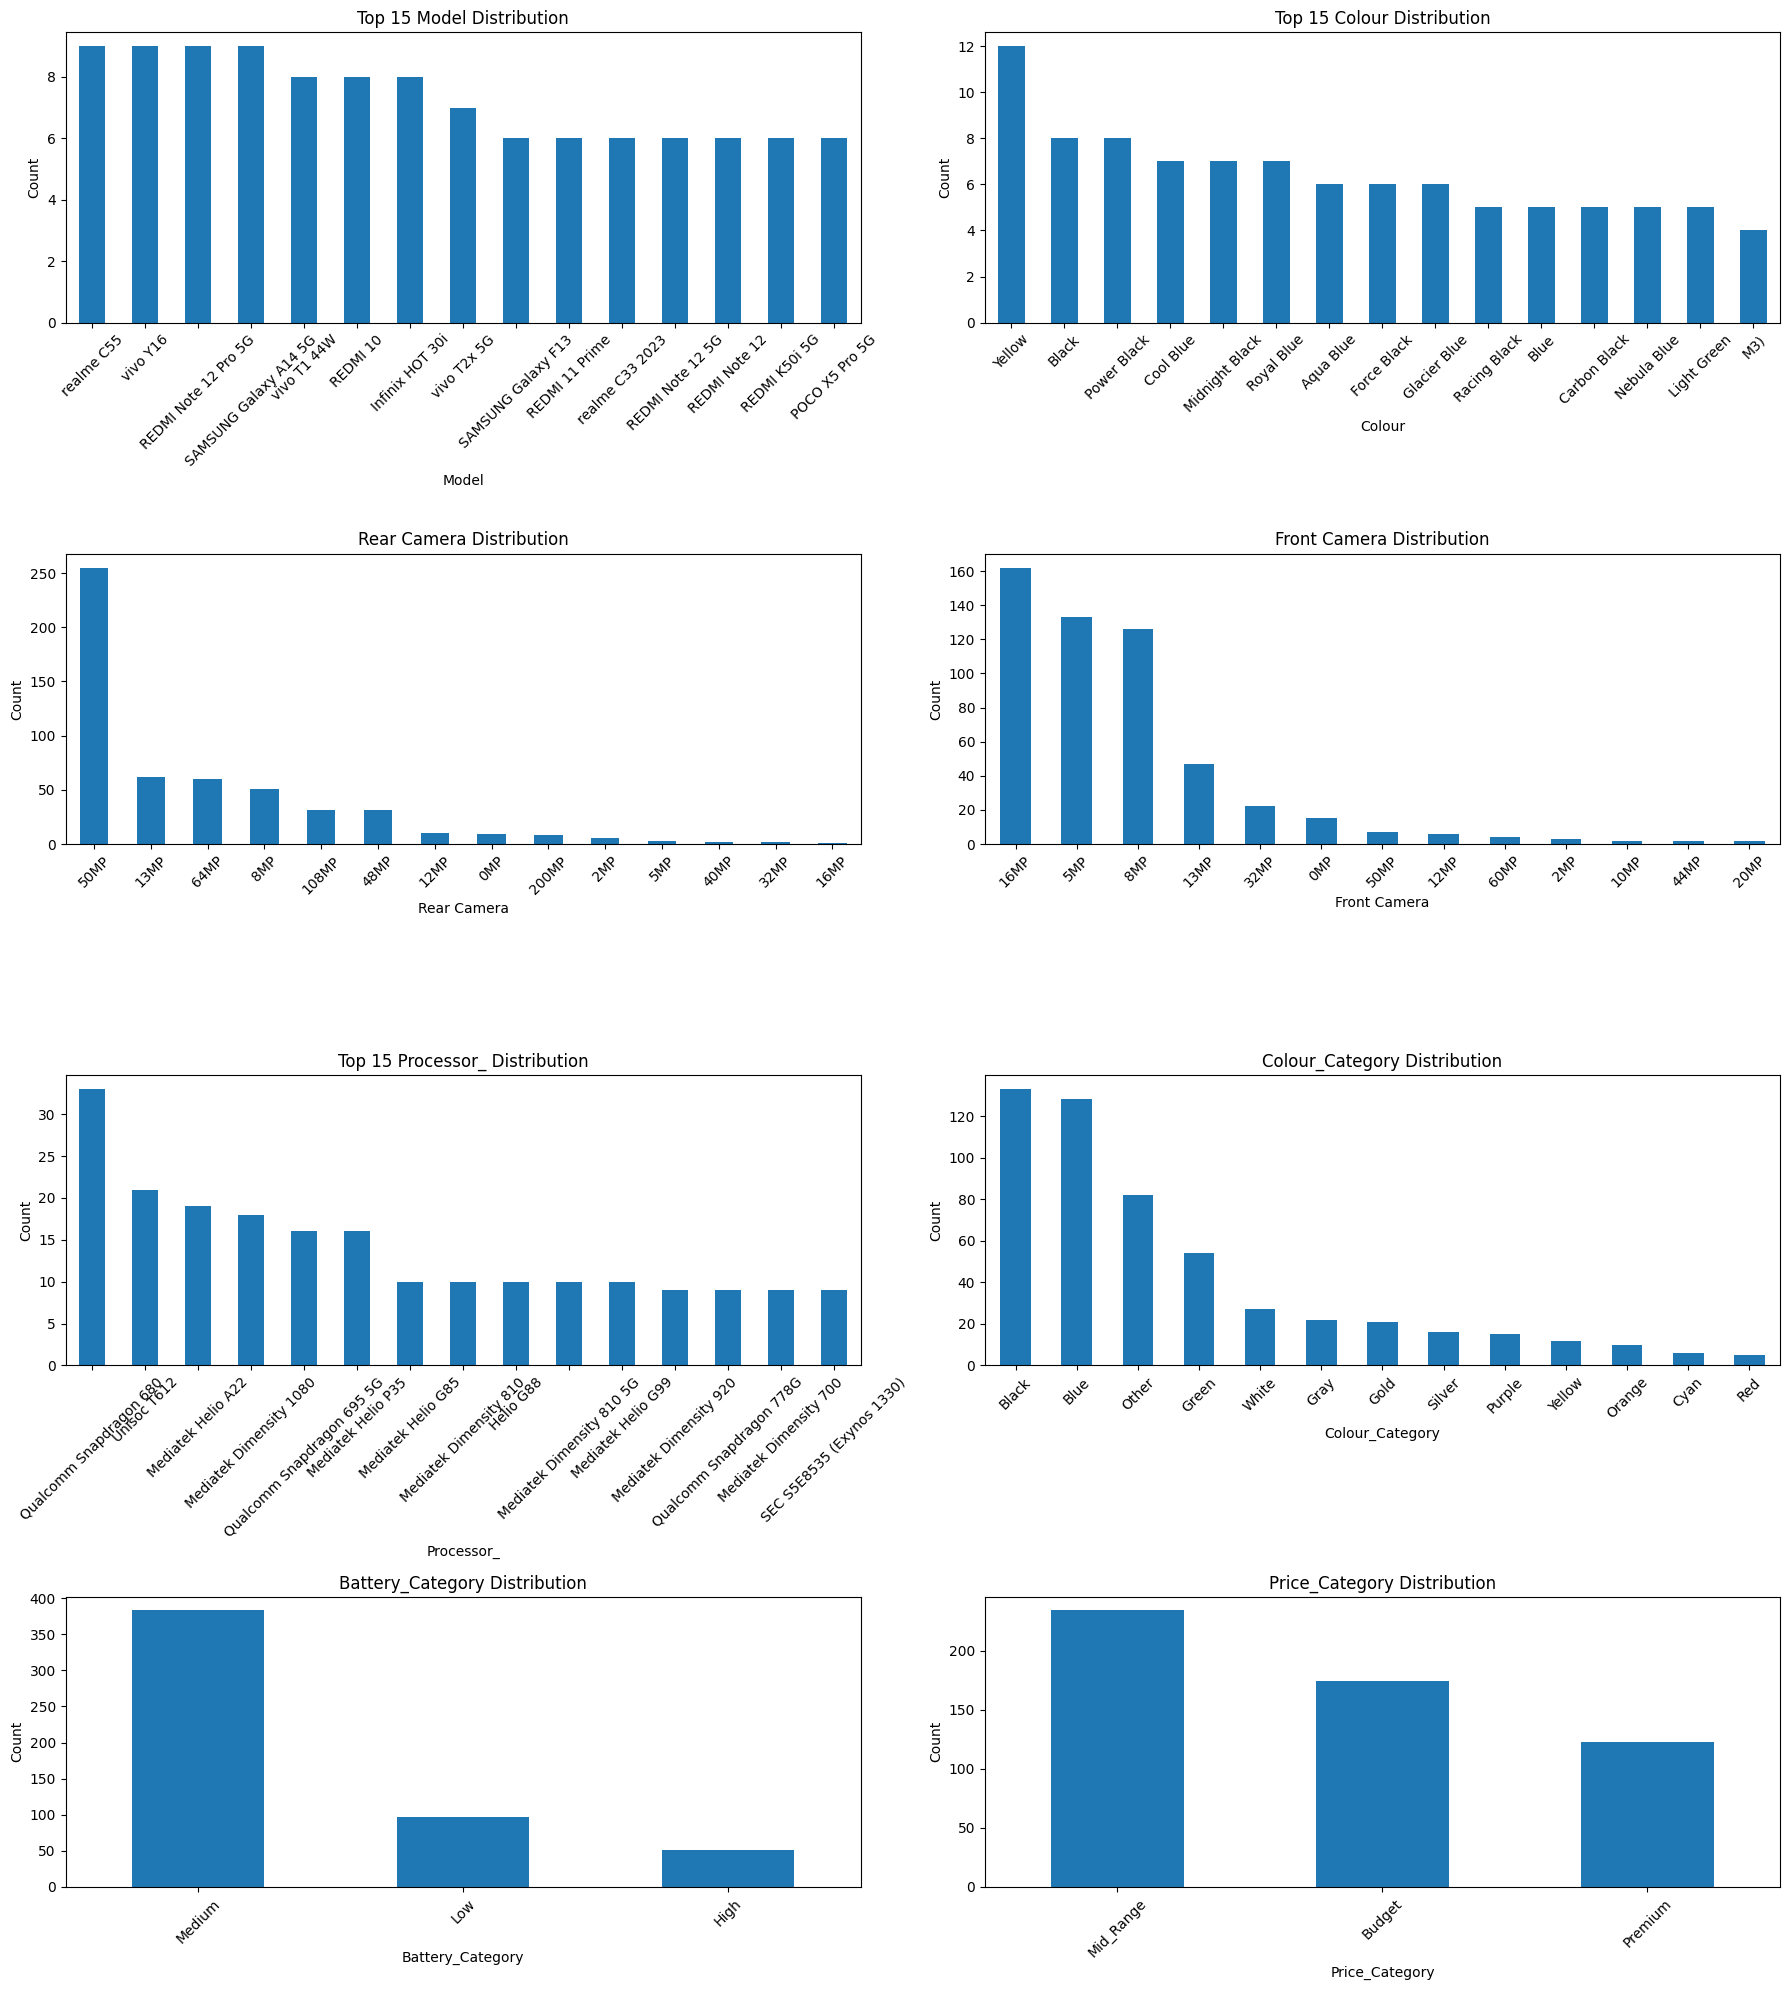

In [38]:
import math
import matplotlib.pyplot as plt

# Automatically extract categorical columns
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns

n_cols = 2
n_rows = math.ceil(len(categorical_cols) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(categorical_cols, 1):

    plt.subplot(n_rows, n_cols, i)

    value_counts = df_clean[col].value_counts()

    # Show Top 15 categories for columns with many unique values
    if value_counts.shape[0] > 15:
        value_counts.head(15).plot(kind='bar')
        plt.title(f"Top 15 {col} Distribution")
    else:
        value_counts.plot(kind='bar')
        plt.title(f"{col} Distribution")

    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

1. Top 15 Model Distribution 

Observation:

The dataset contains a diverse range of smartphone models.
Only the Top 15 most frequent models are displayed to improve visualization readability.
No single model dominates the dataset, indicating a balanced representation of different devices.

Interpretation:

The dataset is not biased toward a particular smartphone model, which helps build a more generalized price prediction model.

---

2. Top 15 Colour Distribution

Observation:

Black is the most common colour, followed by Blue.
Most other colours appear much less frequently.

Interpretation:

Smartphone manufacturers mainly offer devices in neutral colours, while less common colours contribute only a small portion of the dataset.

---

3. Top 15 Processor Distribution

Observation:

A small number of processors appear frequently, whereas many processors have relatively few occurrences.
This indicates an uneven distribution of processor types across devices.

Interpretation:

Popular processor chipsets dominate the market and are expected to have a greater influence during model training than rarely used processors.

---

4. Brand Distribution

Observation:

Realme has the highest number of smartphones in the dataset.
Redmi, Infinix, Vivo, Poco and Samsung are also well represented.
Several brands contain only a few observations.

Interpretation:

The dataset mainly represents popular smartphone brands, making the analysis more relevant to current market trends.

---

5. Colour Category Distribution

Observation:

Black and Blue colour categories are the most frequent.
Bright colours such as Red, Cyan and Orange appear very rarely.

Interpretation:

Consumer preference appears to favor darker and neutral colours over brighter colour options.

---

6. Battery Category Distribution

Observation:

Most smartphones belong to the Medium battery category.
Low battery devices are fewer, while High battery devices represent the smallest group.

Interpretation:

The dataset mainly consists of smartphones with balanced battery capacity, reflecting current market offerings.

---

7. Price Category Distribution

Observation:

Mid-Range smartphones represent the largest category.
Budget phones are the second largest group.
Premium smartphones are comparatively fewer.

Interpretation:

The dataset focuses primarily on the mid-range smartphone market, which is expected to have the greatest influence on the price prediction model.

---

#### Overall Insight

The univariate analysis indicates that the dataset contains a balanced mix of numerical and categorical features representing real-world smartphone specifications. Most devices belong to the mid-range price segment, offer medium battery capacity, and come from popular brands such as Realme, Redmi, Vivo, and Samsung. Memory, RAM, and other hardware specifications show good variability, providing a strong foundation for further relationship analysis in the bivariate and multivariate stages.

## 4.2 Outlier Detection

Purpose 

The purpose of outlier detection is to identify unusually high or low values in numerical features that may affect data analysis and machine learning model performance. Outliers are detected using Box Plots, the Interquartile Range (IQR) method .

### 4.2.1 Box Plot for All Numerical Features

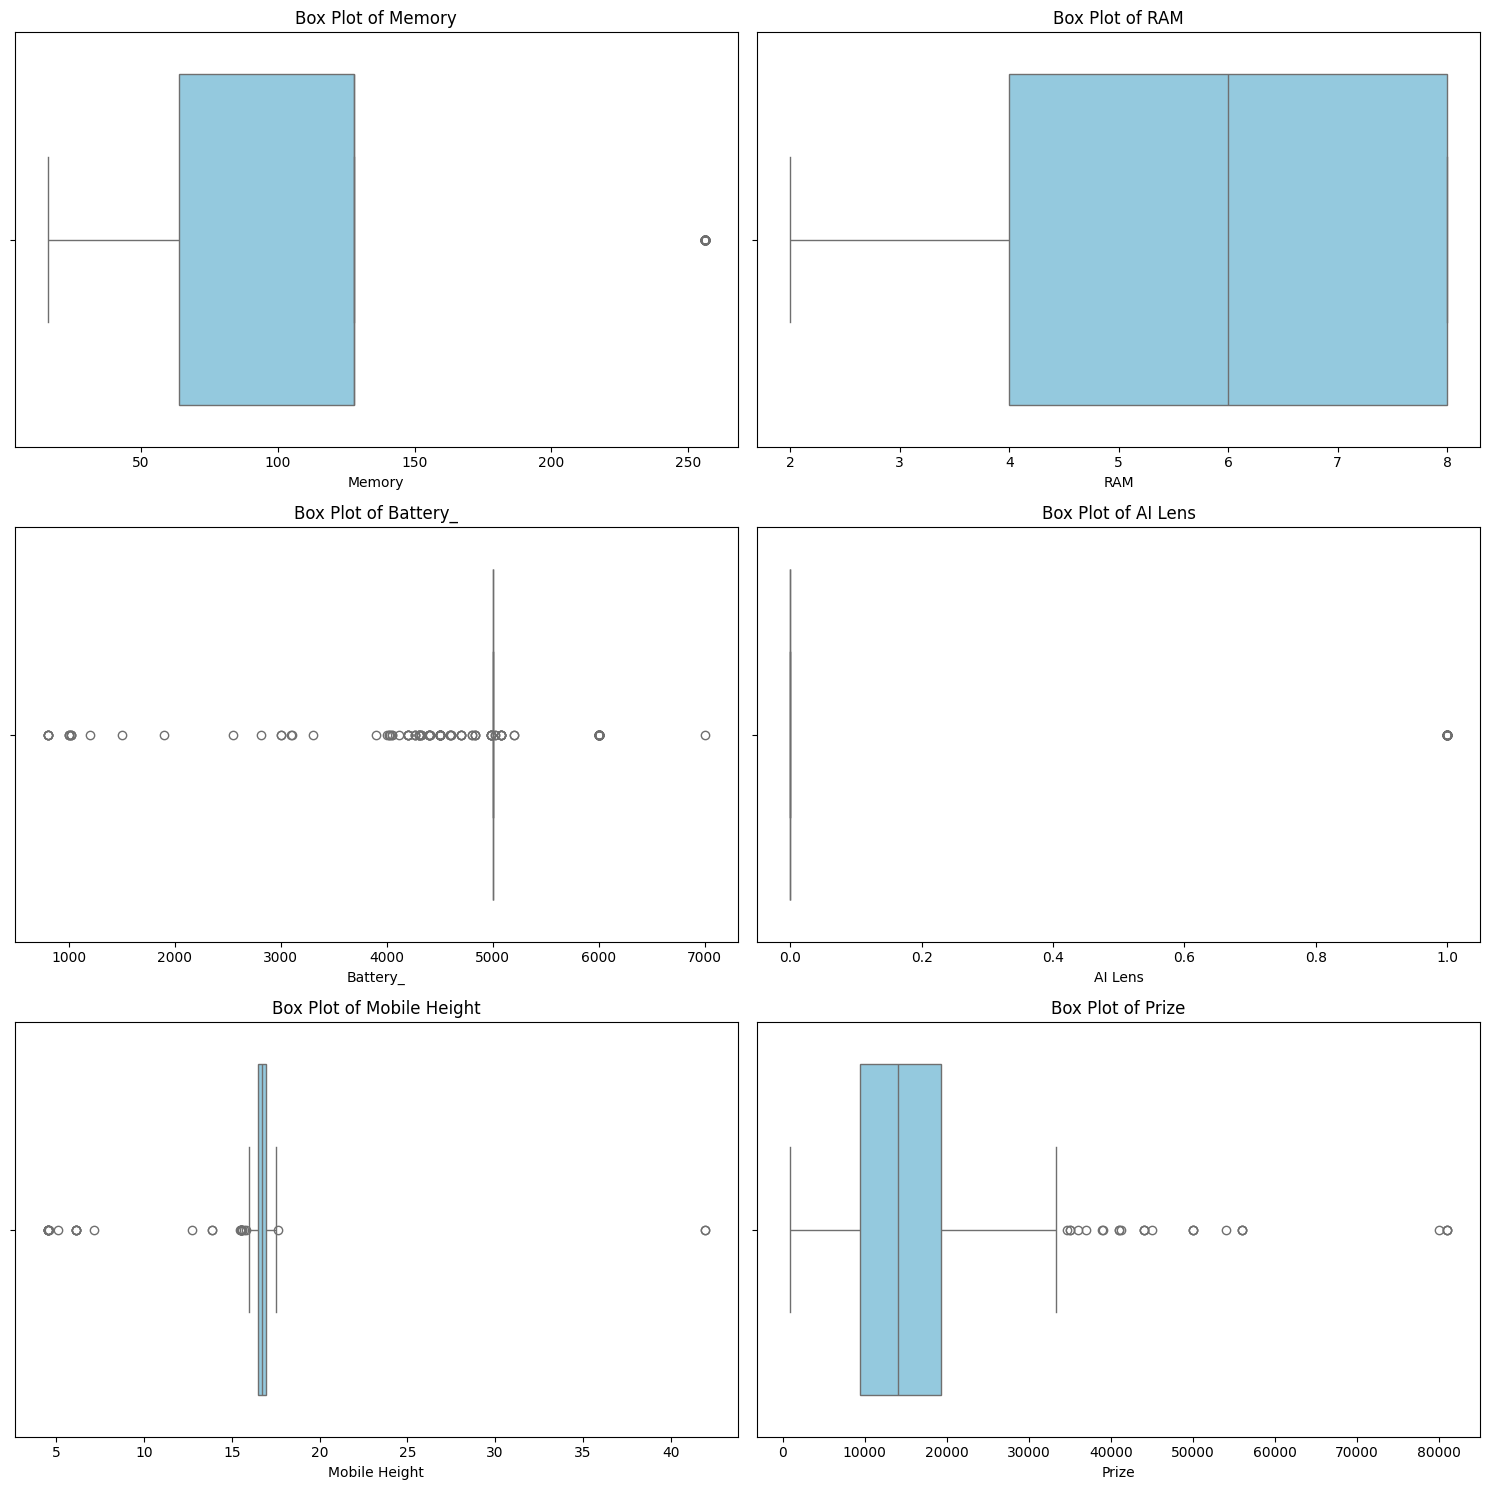

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

n_cols = 2
n_rows = math.ceil(len(numerical_cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df_clean[col], color="skyblue")
    plt.title(f'Box Plot of {col}')

plt.tight_layout()
plt.show()

Observation (Box Plot Analysis) 

1. Memory

Observation:

Most smartphones have memory between 64 GB and 128 GB.
A few 256 GB devices appear as outliers, representing premium storage variants.

---

2. RAM

Observation:

RAM values are mainly concentrated between 4 GB and 8 GB.
No significant outliers are observed, indicating a consistent RAM distribution.

---

3. Battery

Observation:

Most smartphones have battery capacities around 4500–5000 mAh.
A few devices with very low and very high battery capacities appear as outliers.

---

4. Rear Camera

Observation:

Most phones have rear cameras between 13 MP and 64 MP.
High-resolution cameras (around 108 MP and 200 MP) appear as outliers, representing flagship devices.

---

5. Front Camera

Observation:

Most smartphones contain front cameras between 5 MP and 16 MP.
A few models with 32 MP, 50 MP, and 60 MP cameras are detected as outliers.

---

6. AI Lens

Observation:

The AI Lens feature is highly imbalanced, with most devices having 0 (No AI Lens).
Very few smartphones contain an AI Lens, which appears as an outlier.

---

7. Mobile Height

Observation:

Mobile height is concentrated around 15–17 cm.
Only a few devices have unusually small or large dimensions, resulting in outliers.

---

8. Price

Observation:

Most smartphone prices are concentrated in the ₹8,000–₹20,000 range.
Premium smartphones priced above ₹35,000 appear as outliers.

---

9. Total Camera MP

Observation:

Most devices have a total camera resolution between 30 MP and 70 MP.
Smartphones with very high combined camera resolutions appear as outliers.

---

Overall Insight 

The box plots reveal that several numerical features contain outliers, particularly **Price, Rear Camera, Front Camera, Battery Capacity, Mobile Height, Memory, and Total Camera MP**. These extreme values correspond to premium smartphones with advanced specifications rather than data errors. Therefore, the detected outliers were retained to preserve real-world market diversity and improve the robustness of the machine learning model.

---

Conclusion 

Outliers detected through the Box Plot and IQR method were not removed because they represent genuine smartphone specifications rather than incorrect values. Keeping these observations allows the model to learn from both budget and premium devices, resulting in better generalization and more realistic price predictions.

### 4.2.2 Detect Outliers using IQR

Purpose 

To identify and compare the number of outliers present in each numerical feature using the IQR (Interquartile Range) method. This helps understand which features contain extreme values and whether they should be retained for further analysis.

In [40]:
# Detect Outliers using IQR

import pandas as pd

iqr_summary = []

for col in numerical_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]

    iqr_summary.append({
        "Feature": col,
        "Number of Outliers": len(outliers)
    })

iqr_df = pd.DataFrame(iqr_summary)

iqr_df.sort_values(by="Number of Outliers", ascending=False)

,Feature,Number of Outliers
2,Battery_,148
0,Memory,55
3,AI Lens,34
4,Mobile Height,32
5,Prize,25
1,RAM,0


Observation 

- Battery has the highest number of outliers (148).
- Memory contains 55 outliers.
- Rear Camera has 39 outliers.
- AI Lens contains 34 outliers.
- Mobile Height has 32 outliers.
- Price contains 25 outliers.
- Front Camera and Total Camera MP each contain 13 outliers.
- RAM does not contain any outliers according to the IQR method.

Insights 

- Most outliers are found in hardware specification features such as Battery, Memory, and Camera.
- These extreme values represent premium smartphone specifications rather than data errors.
- RAM shows a balanced distribution with no significant outliers.
- Since the dataset contains real market data, these outliers provide valuable information and should be retained for model training.

Conclusion 

The IQR analysis indicates that several numerical features contain genuine outliers, while RAM has none. These outliers correspond to actual high-end smartphone specifications rather than incorrect data entries. Therefore, no outliers were removed, preserving the real-world variability of the dataset.

### 4.2.3 Outlier Handling Decision

Although multiple numerical features contain outliers, these values were retained because they represent genuine smartphone specifications rather than data entry errors.

Removing these observations could eliminate premium flagship devices with naturally higher prices, larger storage capacities, better cameras, or larger batteries.

Therefore, no outliers were removed from the dataset, preserving real-world variability for subsequent machine learning modeling.

## 4.3 Bivariate Analysis

Introduction  

Bivariate Analysis examines the relationship between two variables to understand how one feature influences another. Since the primary objective of this project is to predict smartphone prices, this section focuses on analyzing how different hardware specifications and categorical features affect the price of a smartphone.
Since Prize is our target variable, we first analyze how each important feature affects it.

Objective 

The objective of this analysis is to identify the individual features that have the strongest relationship with smartphone prices and generate meaningful insights that support feature selection and predictive modeling.



### 4.3.1 Relationship Between Numerical Features and Price

Purpose 

The analysis begins with numerical features because hardware specifications such as RAM, Memory, Battery, and Camera directly influence smartphone pricing. Understanding these relationships helps identify the most important predictors for the machine learning model.

#### 4.3.1 (a) Price vs RAM

Purpose 

To examine whether smartphones with higher RAM configurations tend to have higher prices and evaluate the strength of their relationship.

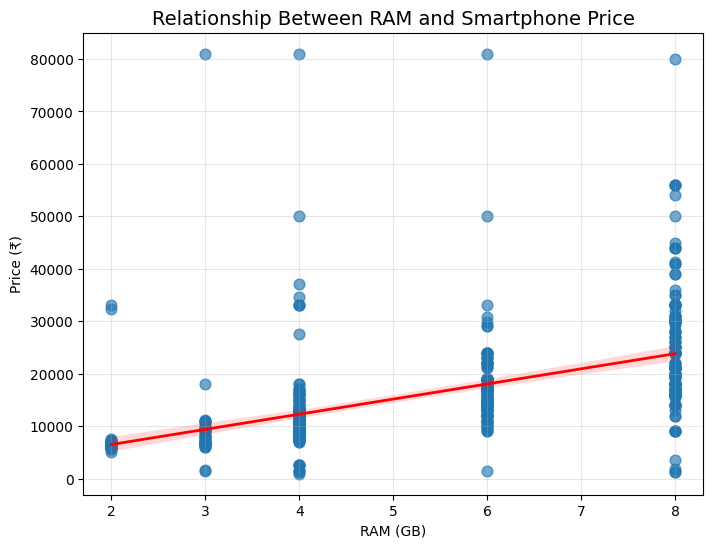

In [41]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_clean,
    x='RAM',
    y='Prize',
    scatter_kws={'alpha':0.65, 's':60},
    line_kws={'color':'red', 'linewidth':2}
)

plt.title("Relationship Between RAM and Smartphone Price", fontsize=14)
plt.xlabel("RAM (GB)")
plt.ylabel("Price (₹)")
plt.grid(alpha=0.3)

plt.show()

Observation 

Smartphone prices generally increase with increasing RAM capacity.
Devices with 6 GB and 8 GB RAM are concentrated in the mid-to-high price range.
A few devices with similar RAM values have different prices, indicating that additional features also influence pricing.

Interpretation 

RAM exhibits a positive relationship with smartphone price. However, the spread of points suggests that RAM alone does not determine the final price, emphasizing the combined effect of multiple hardware specifications.

The analysis indicates that RAM contributes to smartphone pricing. The next step is to determine whether internal storage (Memory) follows a similar trend.

#### 4.3.1 (b) Price vs Memory

Purpose 

To analyze the relationship between smartphone internal storage (Memory) and Price and determine whether devices with larger storage capacities generally have higher prices.

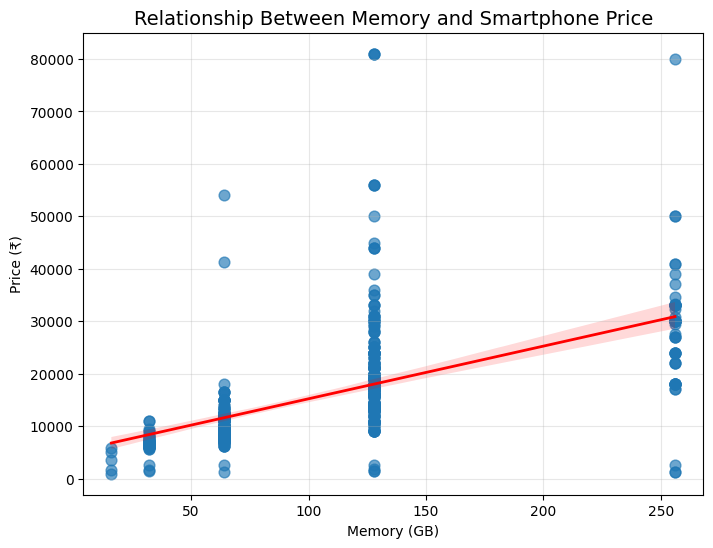

In [42]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_clean,
    x='Memory',
    y='Prize',
    scatter_kws={'alpha':0.65, 's':60},
    line_kws={'color':'red', 'linewidth':2}
)

plt.title("Relationship Between Memory and Smartphone Price", fontsize=14)
plt.xlabel("Memory (GB)")
plt.ylabel("Price (₹)")
plt.grid(alpha=0.3)

plt.show()

Observation 

- Smartphone prices generally increase with larger internal storage capacities.
- Devices with 128 GB and 256 GB storage are mostly concentrated in the higher price range.
- Some smartphones with the same storage capacity have different prices, indicating that processor, RAM, brand, and camera specifications also influence pricing.

Interpretation 

- Internal storage shows a positive relationship with smartphone price. 
- Although higher storage capacity generally leads to higher prices, it is not the only pricing factor.
- Smartphone pricing is influenced by a combination of multiple hardware specifications.

The analysis confirms that both RAM and Memory positively influence smartphone prices. The next step is to examine whether Battery Capacity has a similar impact on smartphone pricing.

#### 4.3.1 (c) Price vs Battery

Purpose

To examine the relationship between smartphone battery capacity and price and determine whether devices with larger battery capacities are generally more expensive.

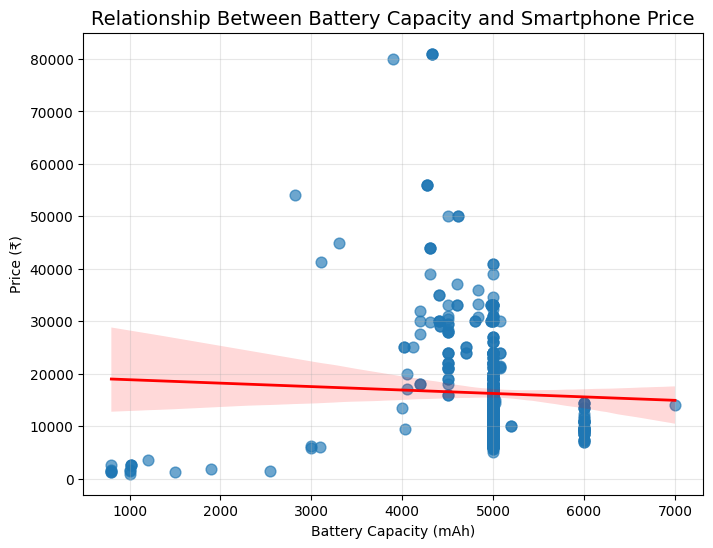

In [43]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_clean,
    x='Battery_',
    y='Prize',
    scatter_kws={'alpha':0.65, 's':60},
    line_kws={'color':'red', 'linewidth':2}
)

plt.title("Relationship Between Battery Capacity and Smartphone Price", fontsize=14)
plt.xlabel("Battery Capacity (mAh)")
plt.ylabel("Price (₹)")
plt.grid(alpha=0.3)

plt.show()

Observation 

- Smartphone prices show a slight positive relationship with battery capacity.
- Most devices are concentrated around 5000 mAh, covering a wide range of prices.
- Smartphones with similar battery capacities often have different prices, indicating that battery capacity alone does not strongly determine smartphone pricing.

Interpretation 

Battery capacity has a weaker influence on smartphone price compared to RAM and Memory. While larger batteries may contribute to higher prices, the overall price is primarily driven by a combination of processor, RAM, storage, camera specifications, and brand.

The analysis indicates that battery capacity alone is not a strong predictor of smartphone price. The next step is to investigate whether rear camera resolution has a stronger relationship with smartphone pricing.

#### 4.3.1 (d) Rear Camera and Price

Purpose 

To analyze the relationship between the rear camera resolution and smartphone price and determine whether devices with higher rear camera specifications are generally more expensive.

In [44]:
# Convert 'Rear Camera' column to numeric by removing 'MP' and converting to numeric type
df_clean['Rear Camera'] = (
    df_clean['Rear Camera']
    .astype(str)
    .str.replace('MP', '', regex=False)
)

df_clean['Rear Camera'] = pd.to_numeric(df_clean['Rear Camera'])

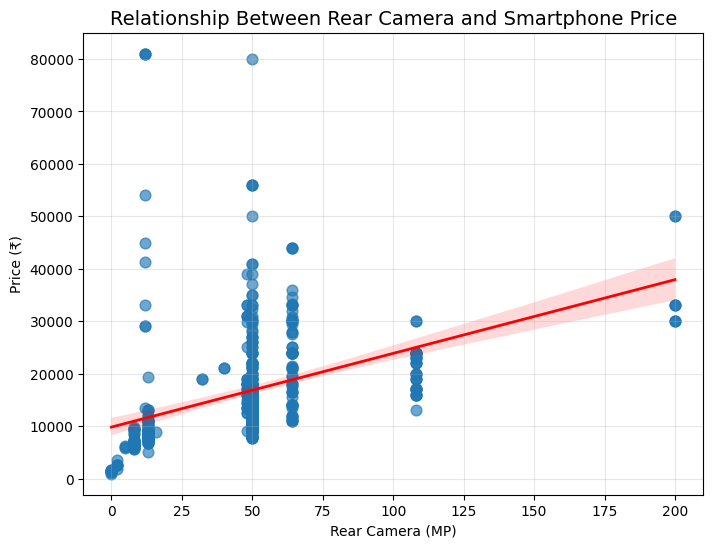

In [45]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_clean,
    x='Rear Camera',
    y='Prize',
    scatter_kws={'alpha':0.65, 's':60},
    line_kws={'color':'red', 'linewidth':2}
)

plt.title("Relationship Between Rear Camera and Smartphone Price", fontsize=14)
plt.xlabel("Rear Camera (MP)")
plt.ylabel("Price (₹)")
plt.grid(alpha=0.3)

plt.show()

Observation 

- Smartphone prices generally increase with higher rear camera resolutions
- Most smartphones are concentrated between 50 MP and 64 MP, covering a broad range of prices.
- Premium smartphones with 108 MP and 200 MP rear cameras are mainly found in the higher price segment.

Interpretation 

Rear camera resolution shows a moderate positive relationship with smartphone price. Although higher-resolution cameras are generally associated with more expensive smartphones, camera quality alone does not determine the final price, as processor, RAM, storage, and brand also play important roles.

The rear camera analysis indicates a moderate positive relationship with smartphone price. Next, we examine whether the front camera specification follows a similar pricing trend.

#### 4.3.1 (e) Front Camera and Price

Purpose 

To analyze the relationship between front camera resolution and smartphone price and determine whether smartphones with higher front camera specifications tend to have higher prices.

In [46]:
print(df_clean[['Front Camera', 'Prize']].dtypes)
print(df_clean[['Front Camera', 'Prize']].head())

Front Camera    object
Prize            int64
dtype: object
  Front Camera  Prize
0          5MP   7299
1          5MP   7299
2         16MP  11999
3          5MP   5649
4          5MP   8999


In [47]:
print(df_clean['Front Camera'].unique()[:15])

['5MP' '16MP' '8MP' '13MP' '0MP' '32MP' '10MP' '50MP' '60MP' '20MP' '44MP'
 '2MP' '12MP']


In [48]:
print(df_clean['Front Camera'].apply(type).value_counts())

Front Camera
<class 'str'>    531
Name: count, dtype: int64


In [49]:
df_clean['Front Camera'] = (
    df_clean['Front Camera']
    .astype(str)
    .str.replace('MP', '', regex=False)
)

df_clean['Front Camera'] = pd.to_numeric(df_clean['Front Camera'])

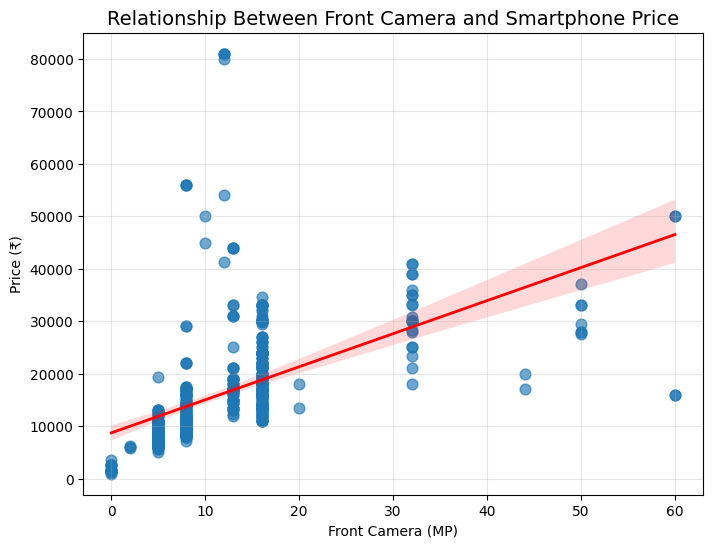

In [50]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_clean,
    x='Front Camera',
    y='Prize',
    scatter_kws={'alpha':0.65, 's':60},
    line_kws={'color':'red', 'linewidth':2}
)

plt.title("Relationship Between Front Camera and Smartphone Price", fontsize=14)
plt.xlabel("Front Camera (MP)")
plt.ylabel("Price (₹)")
plt.grid(alpha=0.3)

plt.show()

Observation 

- Smartphone prices generally increase with higher front camera resolutions.
- Most devices are concentrated between 8 MP and 16 MP, while higher-resolution front cameras appear in comparatively fewer smartphones.
- Some smartphones with similar front camera resolutions have different prices, indicating that additional hardware features also contribute to pricing.

Interpretation 

Front camera resolution has a moderate positive relationship with smartphone price. However, it is not a standalone pricing factor and should be considered together with RAM, storage, processor, rear camera, and brand.

The front camera shows a moderate relationship with smartphone price. The next step is to examine whether the combined camera capability (Total Camera MP) provides a stronger relationship with smartphone pricing.

#### 4.3.1 (f) Total Camera MP and Price

Purpose 

To analyze the relationship between the combined camera resolution (Total Camera MP) and smartphone price and evaluate whether overall camera capability influences pricing.

In [51]:
print(df_clean.columns.tolist())

['Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'Rear Camera', 'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_', 'Prize', 'Colour_Category', 'Battery_Category', 'Price_Category']


In [52]:
# Create Total Camera MP
df_clean['Total_Camera_MP'] = (
    df_clean['Rear Camera'] +
    df_clean['Front Camera']
)

# Verify
df_clean[['Rear Camera','Front Camera','Total_Camera_MP']].head()

,Rear Camera,Front Camera,Total_Camera_MP
0,13,5,18
1,13,5,18
2,50,16,66
3,8,5,13
4,50,5,55


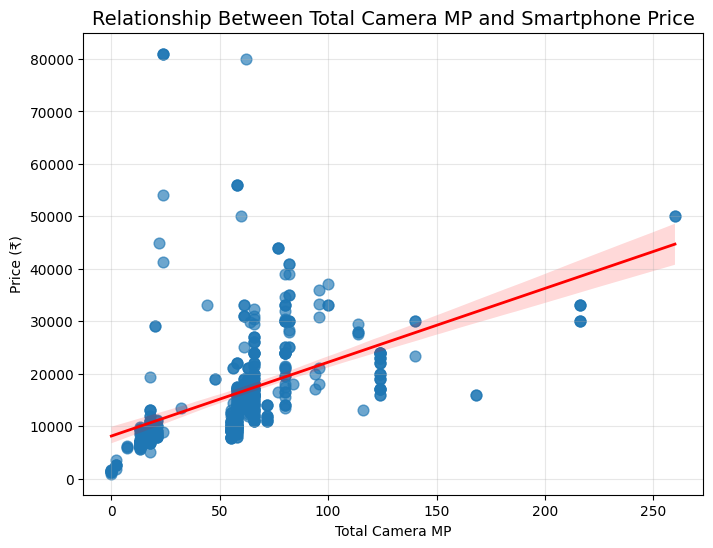

In [53]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_clean,
    x='Total_Camera_MP',
    y='Prize',
    scatter_kws={'alpha':0.65, 's':60},
    line_kws={'color':'red', 'linewidth':2}
)

plt.title("Relationship Between Total Camera MP and Smartphone Price", fontsize=14)
plt.xlabel("Total Camera MP")
plt.ylabel("Price (₹)")
plt.grid(alpha=0.3)

plt.show()

Observation 

- Smartphone prices generally increase as the total camera resolution increases.
- Devices with higher combined camera megapixels are mostly concentrated in the higher price range.
- A few exceptions indicate that camera specifications alone do not fully determine smartphone pricing.

Interpretation 

Total Camera MP shows a positive relationship with smartphone price. Since it combines both rear and front camera specifications, it provides a better representation of overall camera capability than either feature individually.

#### 4.3.1 (g) Feature Interaction: Total_Camera_MP

Purpose 

Mobile phone photography depends on both rear and front cameras. Combining these specifications into a single feature provides a better representation of the overall camera capability of each device.

In [54]:
# Remove 'MP' only if it exists
df_clean['Rear Camera'] = (
    df_clean['Rear Camera']
    .astype(str)
    .str.replace('MP', '', regex=False)
)

df_clean['Front Camera'] = (
    df_clean['Front Camera']
    .astype(str)
    .str.replace('MP', '', regex=False)
)

# Convert to numeric
df_clean['Rear Camera'] = pd.to_numeric(df_clean['Rear Camera'])
df_clean['Front Camera'] = pd.to_numeric(df_clean['Front Camera'])

# Create Total Camera MP
df_clean['Total_Camera_MP'] = (
    df_clean['Rear Camera'] +
    df_clean['Front Camera']
)

# Verify
df_clean[['Rear Camera','Front Camera','Total_Camera_MP']].head()

,Rear Camera,Front Camera,Total_Camera_MP
0,13,5,18
1,13,5,18
2,50,16,66
3,8,5,13
4,50,5,55


Observation 

A new feature named Total_Camera_MP was created by combining the Rear Camera and Front Camera megapixel values. The sample output confirms that the values have been correctly calculated (e.g., 13 + 5 = 18 and 50 + 16 = 66). This combined feature provides a better representation of the smartphone's overall camera capability and is ready to be used for further analysis.

#### Overall Insight

The bivariate analysis indicates that smartphone price generally increases with improvements in hardware specifications. RAM, Memory, Rear Camera, Front Camera, and Total Camera MP all show positive relationships with price, while Battery Capacity exhibits a comparatively weaker relationship. These findings suggest that smartphone pricing is influenced by multiple hardware specifications rather than any single feature.

### 4.3.2 Relationship Between Categorical Features and Price

Purpose 

To analyze how categorical features such as Brand, Battery Category, and Price Category are associated with smartphone prices. This analysis helps identify which groups contribute most to price variation.

#### 4.3.2. (a) Brand vs Price

Purpose 

To compare the price distribution across different smartphone brands and identify which brands generally offer higher-priced devices.

In [55]:
df_clean['Brand'] = df_clean['Model'].str.split().str[0]

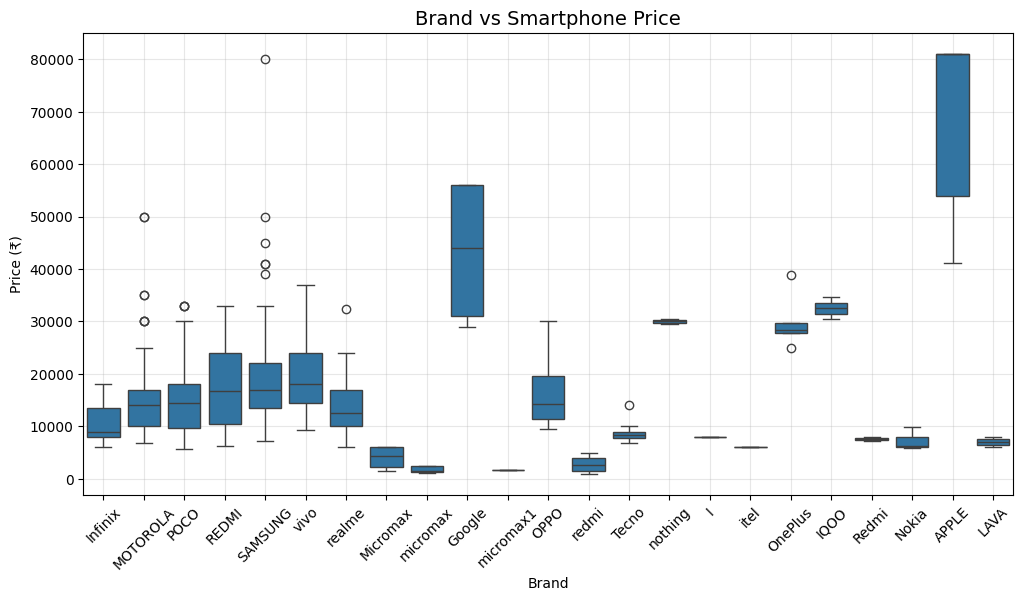

In [56]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_clean,
    x='Brand',
    y='Prize'
)

plt.title("Brand vs Smartphone Price", fontsize=14)
plt.xlabel("Brand")
plt.ylabel("Price (₹)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

Observation 

- Apple smartphones have the highest median price among all brands, indicating a strong premium market position.
- Google smartphones also belong to the higher price segment with a wider price distribution.
- Samsung, Vivo, Redmi, Poco, Motorola, and Infinix mainly fall within the low to mid-price range, although Samsung and Vivo include several higher-priced models.
- Realme, Oppo, and Tecno primarily offer budget to mid-range smartphones with relatively lower median prices.
- Several brands (especially Samsung, Motorola, Vivo, and Redmi) contain outliers, indicating the presence of premium models alongside affordable devices.
- Apple shows comparatively fewer variations within its product range, suggesting a stronger focus on premium smartphones.

Interpretation 

The analysis indicates that brand significantly influences smartphone pricing. Premium brands such as Apple and Google consistently maintain higher prices, whereas brands like Redmi, Realme, Infinix, Poco, and Tecno primarily compete in the budget and mid-range market. The presence of outliers for brands like Samsung and Vivo suggests that these companies cater to multiple customer segments by offering both affordable and flagship devices. Overall, brand positioning is an important factor affecting smartphone prices in the dataset.

#### (b) 4.3.2 Create Price_Category
Purpose 

Although the target variable for machine learning remains continuous (Prize), creating a Price_Category feature helps compare pricing segments during exploratory data analysis.

In [57]:
df_clean['Brand'] = df_clean['Model'].str.split().str[0]
df_clean[['Model','Brand']].head()

,Model,Brand
0,Infinix SMART 7,Infinix
1,Infinix SMART 7,Infinix
2,MOTOROLA G32,MOTOROLA
3,POCO C50,POCO
4,Infinix HOT 30i,Infinix


In [58]:
df_clean['Brand'] = df_clean['Brand'].str.title()
df_clean['Brand'].unique()

array(['Infinix', 'Motorola', 'Poco', 'Redmi', 'Samsung', 'Vivo',
       'Realme', 'Micromax', 'Google', 'Micromax1', 'Oppo', 'Tecno',
       'Nothing', 'I', 'Itel', 'Oneplus', 'Iqoo', 'Nokia', 'Apple',
       'Lava'], dtype=object)

In [59]:
print("Number of unique brands: ", df_clean['Brand'].nunique()) 
df_clean['Brand'].value_counts()



Number of unique brands:  20


Brand
Realme       97
Redmi        74
Infinix      65
Vivo         60
Poco         58
Samsung      53
Motorola     45
Tecno        16
Oppo         16
Micromax     13
Google        9
Oneplus       5
Apple         5
Nokia         3
Itel          3
Nothing       2
Iqoo          2
I             2
Lava          2
Micromax1     1
Name: count, dtype: int64

Observation 

The `Brand` feature was created by extracting the manufacturer name from the 'Model' column. This feature provides a clearer representation of mobile phone brands and can be useful for analyzing brand-wise price variations.

The relationship between brand and smartphone price highlights clear pricing differences across manufacturers. To gain deeper insights into market segmentation, the next analysis examines how different price categories are distributed across brands using a grouped comparison.

#### 4.3.2 (c) Brand-wise Price Category Distribution

Purpose 

To analyze how smartphone brands are distributed across different price categories (Budget, Mid-Range, and Premium). This helps identify each brand's market positioning and target customer segment.


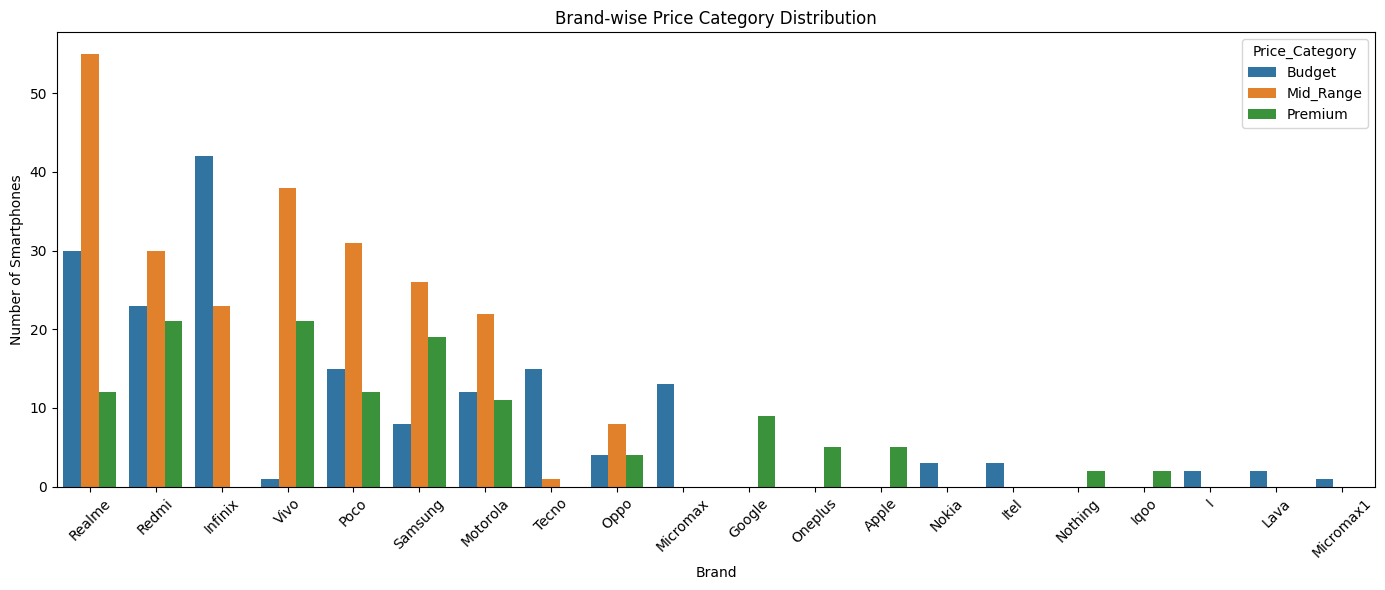

In [60]:
plt.figure(figsize=(14,6))

sns.countplot(
    data=df_clean,
    x='Brand',
    hue='Price_Category',
    order=df_clean['Brand'].value_counts().index
)

plt.title('Brand-wise Price Category Distribution')
plt.xlabel('Brand')
plt.ylabel('Number of Smartphones')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Observation 

- Realme has the highest number of Mid-Range smartphones, indicating a strong focus on this segment.
- Infinix mainly offers Budget smartphones, with very few premium devices.
- Redmi, Vivo, Samsung, Poco, and Motorola provide smartphones across all three price categories, showing a diverse product portfolio.
- Google, Apple, and OnePlus are concentrated mainly in the Premium category, targeting high-end customers.
- Tecno and Micromax primarily belong to the Budget segment.
- Premium smartphones are comparatively fewer than Budget and Mid-Range models across most brands.

Interpretation 

- The chart shows that different brands follow different pricing strategies. 
- Brands such as Apple, Google, and OnePlus focus mainly on the premium market, whereas Infinix, Tecno, and Micromax target budget-conscious customers. 
- Brands like Samsung, Vivo, Redmi, Poco, and Motorola maintain a balanced portfolio by offering smartphones across multiple price categories, allowing them to serve a wider customer base.

The relationship between brand and price category explains how different manufacturers position their products in the market. After understanding brand-wise pricing strategies, the next step is to analyze how hardware specifications, such as RAM and Memory, jointly influence smartphone prices.

### 4.3.3 Relationship Between RAM and Memory

Purpose 

Analyze the relationship between RAM and Internal Memory across different Price Categories to understand how smartphone storage configurations vary with market segments.

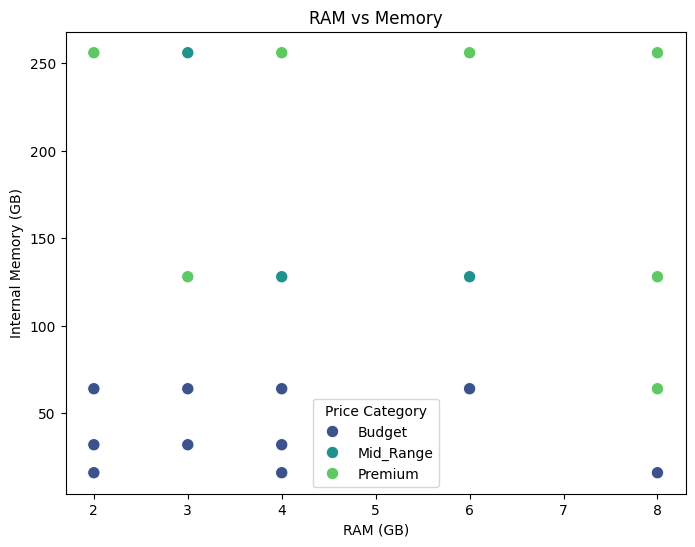

In [61]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_clean,
    x='RAM',
    y='Memory',
    hue='Price_Category',
    palette='viridis',
    s=80
)

plt.title("RAM vs Memory")
plt.xlabel("RAM (GB)")
plt.ylabel("Internal Memory (GB)")
plt.legend(title="Price Category")
plt.show()

Observation 

- Budget smartphones are mainly concentrated in 2–4 GB RAM and 32–64 GB Memory.
- Mid-Range smartphones are commonly available with 4–6 GB RAM and 64–128 GB Memory.
- Premium smartphones are mostly associated with 8 GB RAM and 128–256 GB Memory.
- As RAM increases, the available internal memory generally also increases.
- Very few Budget devices provide high RAM and high Memory configurations.

Interpretation 

- The chart indicates a positive relationship between RAM and Internal Memory.
- Smartphones with higher RAM usually offer larger storage capacity and are more likely to belong to the Premium category, while Budget devices are clustered around lower hardware configurations.

Overall Insight 

RAM and Internal Memory increase together and are strong indicators of smartphone price category. These two features are likely to be important predictors for the machine learning model when estimating smartphone prices.

After understanding the relationship between RAM and Internal Memory across different price segments, the next step is to examine how multiple hardware features jointly influence smartphone prices through multivariate analysis.

### 4.3.4 Relationship between Battery Capacity vs Price

Purpose 

Analyze the relationship between Battery Capacity and Smartphone Price across different Price Categories to determine whether larger battery capacity contributes to higher smartphone prices.

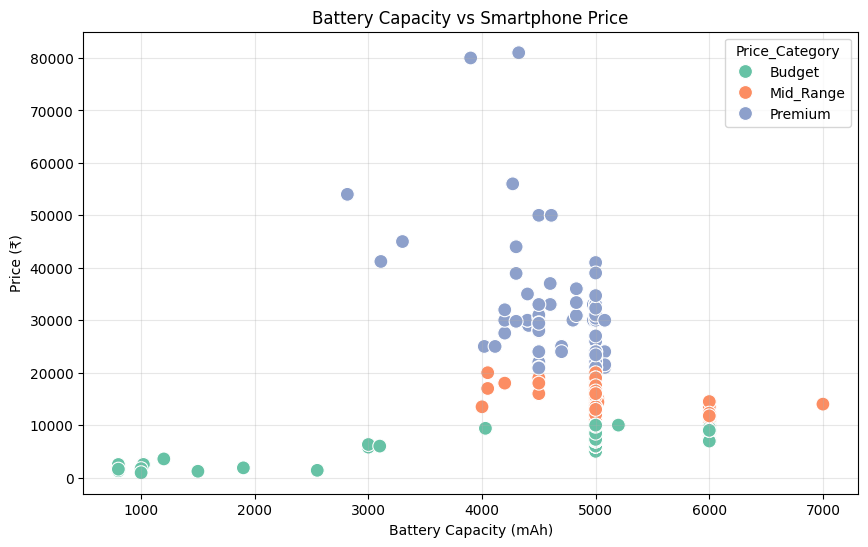

In [62]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_clean,
    x='Battery_',
    y='Prize',
    hue='Price_Category',
    palette='Set2',
    s=100
)

plt.title("Battery Capacity vs Smartphone Price")
plt.xlabel("Battery Capacity (mAh)")
plt.ylabel("Price (₹)")
plt.grid(alpha=0.3)

plt.show()

Observation 

- Most smartphones are concentrated between 4000 mAh and 5000 mAh battery capacity.
- Premium smartphones are generally priced higher, even when they have similar battery capacities as Budget and Mid-Range devices.
- Budget smartphones mostly fall in the lower price range despite offering large batteries.
- Several Premium smartphones with 4000–5000 mAh batteries are priced significantly higher than other categories.
-Smartphones with extremely small battery capacities (below 3000 mAh) mostly belong to the Budget category.

Interpretation 

- Battery capacity alone does not strongly determine smartphone price. 
- Smartphones with similar battery capacities can belong to different price categories because pricing also depends on specifications such as RAM, Memory, Processor, Camera quality, and Brand value.

Overall Insight 

The analysis suggests that Battery Capacity has only a weak influence on smartphone price. While modern smartphones commonly offer batteries around 4000–5000 mAh, Premium devices achieve higher prices primarily because of better overall hardware specifications rather than battery size alone.

The Bivariate Analysis explained how individual features such as RAM, Memory, Battery Capacity, and Brand are related to smartphone price. However, smartphone pricing is influenced by multiple features working together rather than a single feature alone. Therefore, the next step is Multivariate Analysis, which examines the combined relationships among several variables to gain deeper insights into the factors affecting smartphone prices.

## 4.4 Multivariate Analysis

Introduction 

Multivariate Analysis examines the relationship among three or more variables simultaneously. Unlike Univariate and Bivariate Analysis, it provides a deeper understanding of how multiple smartphone features collectively influence the target variable (Price). This analysis helps identify complex interactions, feature dependencies, and patterns that are valuable for both business insights and machine learning model development.

Objective 

- Analyze the combined impact of multiple smartphone features on price.
- Identify relationships among numerical and categorical variables simultaneously.
- Understand how hardware specifications collectively affect smartphone pricing.
- Discover important feature interactions for machine learning.
- Support feature selection and improve model performance through data-driven insights.

### 4.4.1 Correlation Heatmap of Numerical Features

Purpose 

To examine the interaction among multiple numerical features using a correlation matrix. This analysis helps identify positive and negative relationships, detect multicollinearity, and determine which hardware specifications have the strongest association with smartphone price.

### Feature Interaction

Before analyzing multiple variables together, it is important to understand how numerical features interact with one another.

The correlation heatmap measures the strength and direction of relationships between numerical variables such as RAM, Memory, Battery Capacity, Rear Camera, Front Camera, Total Camera MP, and Price.

This interaction analysis helps identify which features are closely associated with smartphone price and provides a strong foundation for machine learning feature selection.

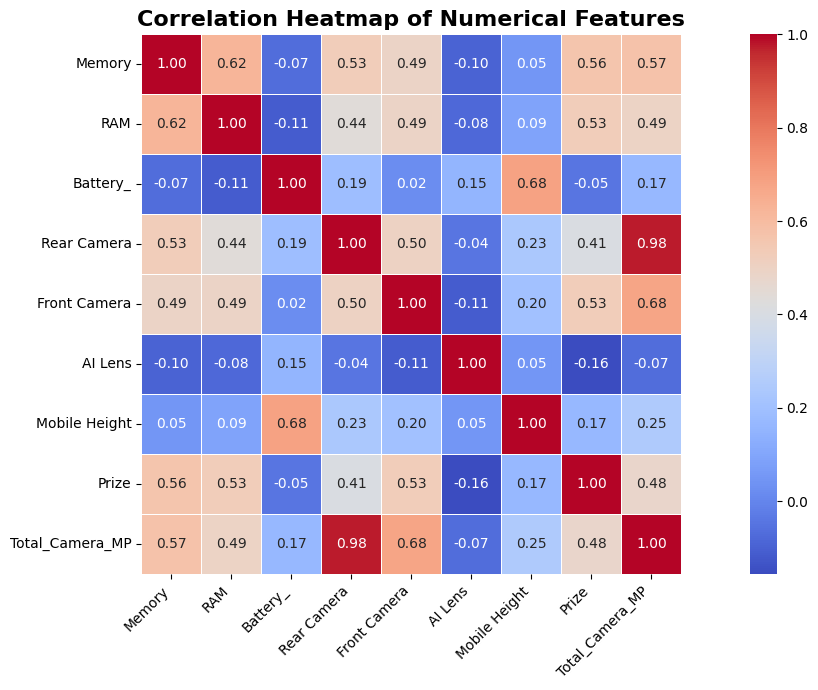

In [63]:
# Select only numerical columns
corr_df = df_clean.select_dtypes(include='number').copy()

# Remove Price_Zscore (not required as per project)
if 'Price_Zscore' in corr_df.columns:
    corr_df = corr_df.drop(columns=['Price_Zscore'])

# Compute correlation matrix
corr_matrix = corr_df.corr()

# Plot Heatmap
plt.figure(figsize=(14, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar=True,
    annot_kws={"size":10}
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Observation 

- Memory and RAM show a moderately strong positive correlation (0.62), indicating that smartphones with higher RAM generally also provide higher internal storage.
- Rear Camera and Total_Camera_MP exhibit an extremely strong positive correlation (0.98). This is expected because Total_Camera_MP is an engineered feature created by combining the rear and front camera resolutions.
- Battery Capacity and Mobile Height have a moderate positive correlation (0.68), suggesting that larger batteries are generally found in slightly larger smartphones.
- Front Camera and Total_Camera_MP also exhibit a moderately strong positive correlation (0.68), indicating that improvements in total camera quality are associated with better front cameras.

Price has a moderate positive correlation with:

Memory (0.56)

RAM (0.53)

Front Camera (0.53)

Rear Camera (0.41)

- This indicates that smartphones with better specifications generally have higher prices.

- Battery Capacity (-0.05) and AI Lens (-0.16) show very weak or negligible correlation with Price, suggesting these features alone do not strongly influence smartphone pricing.
- Most remaining feature pairs have weak-to-moderate correlations, indicating that each feature contributes different information to the dataset.

Interpretation  

The correlation analysis indicates that Memory, RAM, and camera-related specifications have the strongest positive relationship with smartphone price. The engineered feature Total_Camera_MP captures the combined effect of rear and front cameras and therefore exhibits a stronger association than the individual camera features. Battery Capacity and AI Lens show weak linear relationships with price, suggesting that smartphone pricing depends on multiple hardware specifications rather than a single feature.

Key Insights 

- Memory and RAM increase together in most smartphones.
- Price is positively associated with better storage, RAM, and camera specifications.
- The engineered feature Total_Camera_MP successfully captures the overall camera capability and can be considered a useful predictor for smartphone price.
- Battery Capacity alone is not a strong indicator of smartphone price.
- AI Lens has almost no linear relationship with price.
- Overall, the dataset shows meaningful relationships without excessive multicollinearity among most features, making it suitable for predictive modeling.

Final Conclusion 

The multivariate correlation analysis shows that smartphone price is influenced by multiple hardware specifications rather than a single feature. Memory, RAM, and camera-related features contribute the most to pricing, while the engineered feature Total_Camera_MP provides a better representation of overall camera capability. These findings help identify important features for predictive modeling and support the feature selection process in machine learning.

After examining the correlation between numerical features, the next step is to use a Pair Plot to visualize pairwise relationships and understand how numerical features interact across different Price Categories (Budget, Mid-Range, and Premium). This provides deeper insights into feature distributions and class separation.

### 4.4.2 Pair Plot of Important Numerical Features

Purpose :

The purpose of the Pair Plot is to visualize the relationships among multiple numerical features simultaneously. It helps identify patterns, feature interactions, clusters, correlations, and the separation of different smartphone price categories (Budget, Mid-Range, and Premium).

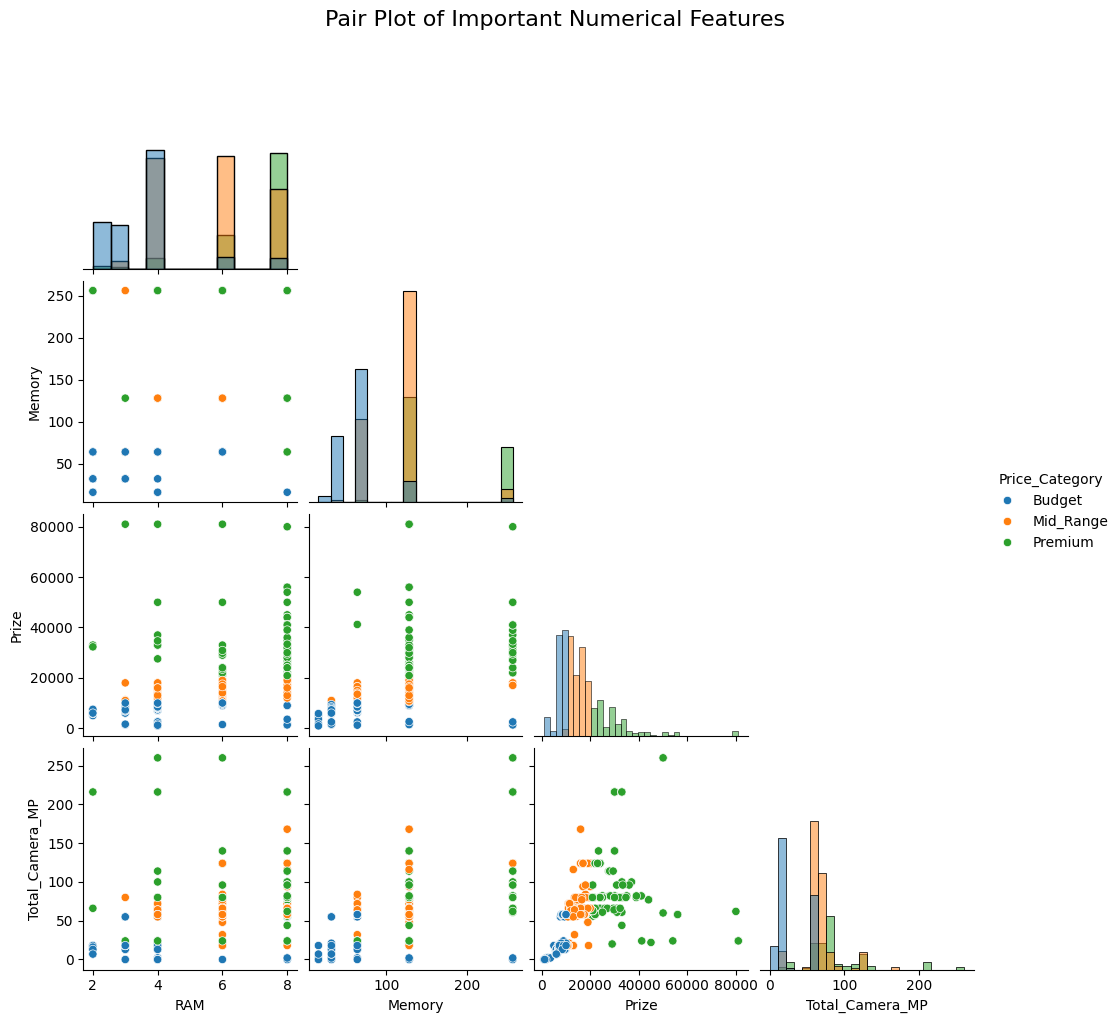

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

pairplot_columns = [
    'RAM',
    'Memory',
    'Prize',
    'Total_Camera_MP',
    'Price_Category'
]

sns.pairplot(
    df_clean[pairplot_columns],
    hue='Price_Category',
    diag_kind='hist',
    corner=True,
    height=2.5
)

plt.suptitle("Pair Plot of Important Numerical Features", y=1.02, fontsize=16)
plt.show()

Conclusion

The Pair Plot confirms that smartphones with higher RAM, larger storage, better camera specifications, and higher Total Camera MP are generally associated with higher prices. The engineered Price_Category successfully groups smartphones into meaningful market segments, making it useful for predictive modeling and feature selection.

Observation :

1. RAM vs Price

Smartphones with higher RAM (6GB–8GB) are predominantly classified as Premium devices, while 2GB–4GB devices mostly belong to the Budget category.

2. Memory vs Price

Devices with 128GB and 256GB storage are mainly Premium smartphones, whereas 32GB and 64GB storage are common among Budget and Mid-Range devices.

3. Total Camera MP vs Price

Total Camera MP shows a clear positive association with smartphone price. Premium smartphones generally have higher combined camera resolutions.

4. RAM vs Memory

RAM and Memory exhibit a positive relationship, indicating that smartphones with larger RAM usually provide higher internal storage.

5. Price Category Separation

Budget, Mid-Range, and Premium smartphones form visible clusters with only slight overlap, indicating that the engineered Price_Category effectively separates the dataset.

6. Overall Feature Interaction

RAM, Memory, Price, and Total Camera MP show consistent positive interactions, suggesting that premium smartphones combine multiple high-end specifications rather than relying on a single feature.

Interpretation :

The Pair Plot demonstrates that RAM, Memory, and Total Camera MP increase together with smartphone price. Premium smartphones clearly occupy the higher end of these specifications, while Budget devices remain clustered at lower values. The visualization also confirms that the engineered Price_Category successfully distinguishes smartphones based on their hardware configurations.The pair plot also highlights that smartphone pricing depends on the combined influence of multiple hardware specifications rather than any single feature alone.

Key Insights :

- Premium smartphones generally have higher RAM, larger storage, and better camera specifications.
- Budget smartphones are concentrated around lower RAM, smaller storage, and lower prices.
- Memory and RAM exhibit a positive relationship.
- Total Camera MP increases with smartphone price.
- The three price categories are well separated, indicating meaningful feature engineering.
- Overall, the selected numerical features effectively differentiate smartphone segments.
- Some overlap exists between Mid-Range and Premium devices, indicating that certain mid-range smartphones offer flagship-level specifications.

After understanding the pairwise relationships among important numerical features, the next step is to build a 3D Scatter Plot to visualize the combined effect of RAM, Memory, and Price simultaneously. This provides a clearer understanding of how multiple features interact in three-dimensional space.

### 4.4.3 3D Scatter Plot (RAM vs Memory vs Price)

Purpose 

To visualize the interaction among RAM, Memory, and Smartphone Price simultaneously in three-dimensional space. This analysis helps identify whether smartphones with higher RAM and storage capacities are generally associated with higher prices and reveals the clustering of Budget, Mid-Range, and Premium smartphones.

Feature Interaction 

Unlike pair plots, a 3D scatter plot allows three numerical variables to be analyzed simultaneously. It provides a better understanding of how multiple hardware specifications collectively influence smartphone pricing.

The visualization also highlights whether different price categories occupy distinct regions in the feature space.

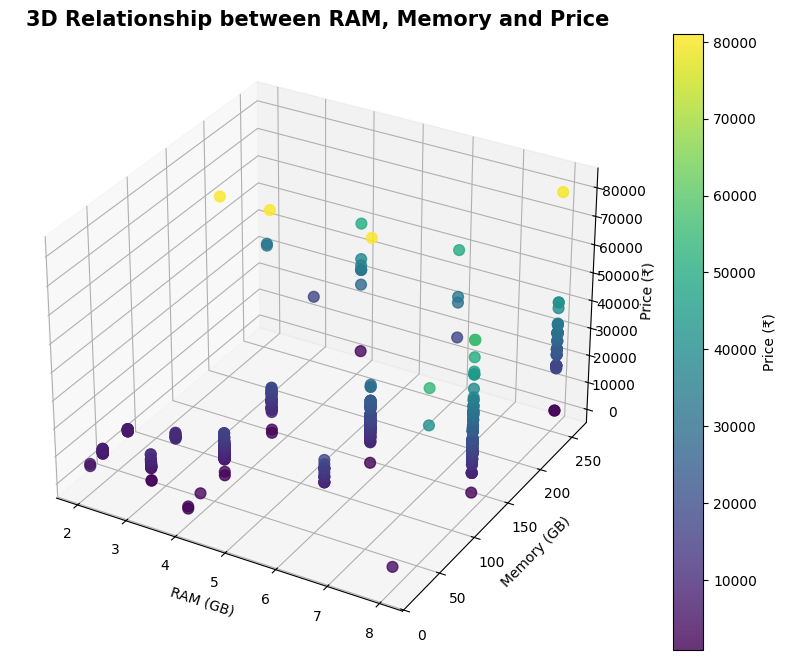

In [82]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_clean['RAM'],
    df_clean['Memory'],
    df_clean['Prize'],
    c=df_clean['Prize'],
    cmap='viridis',
    s=60,
    alpha=0.8
)

ax.set_title("3D Relationship between RAM, Memory and Price", fontsize=15, fontweight='bold')

ax.set_xlabel("RAM (GB)")
ax.set_ylabel("Memory (GB)")
ax.set_zlabel("Price (₹)")

plt.colorbar(scatter, label='Price (₹)')

plt.show()

Observation 

1. RAM vs Memory vs Price
Smartphones with higher RAM (6GB–8GB) and larger Memory (128GB–256GB) generally have higher prices, indicating a positive multivariate relationship.

2. Premium Device Distribution
Most high-priced smartphones are concentrated in the region with high RAM, high Memory, and high Price, forming a distinct premium cluster.

3. Budget Device Distribution
Budget smartphones are primarily located in the lower region of the plot, characterized by 2GB–4GB RAM, 32GB–64GB Memory, and lower prices.

4. Mid-Range Transition
Mid-range smartphones occupy the middle region of the plot, acting as a transition between Budget and Premium devices.

5. Overall Trend
The data points show an overall upward pattern, suggesting that smartphone price generally increases as RAM and Memory increase.

6. Price Variation
A few smartphones with similar RAM or Memory have different prices, indicating that additional features (such as processor, camera, or brand) also influence pricing.

Interpretation 

The 3D Scatter Plot demonstrates that RAM and internal storage jointly have a strong influence on smartphone price. Smartphones with better hardware configurations are generally positioned in the higher-price region, while lower-specification devices remain concentrated at lower price levels. The visualization indicates that smartphone pricing depends on the combined effect of multiple hardware specifications rather than any single feature alone, making RAM and Memory valuable predictors for machine learning models.

Key Insights 

- Higher RAM is generally associated with larger internal storage.
- Smartphones with higher RAM and Memory typically command higher prices.
- Premium smartphones occupy the upper region of the 3D feature space.
- Budget smartphones are clustered in the lower-specification region.
- Mid-range smartphones bridge the gap between Budget and Premium segments.
- Some price variation exists among devices with similar specifications, suggesting that other hardware features also contribute to pricing.
- The visualization confirms that RAM and Memory are important features for predicting smartphone prices and support their inclusion in machine learning models.

After visualizing the combined relationship among RAM, Memory, and Price in three-dimensional space, the next step is to analyze how camera quality influences smartphone pricing while simultaneously considering price categories. A Bubble Chart enables the visualization of four variables in a single plot, providing deeper insights into multivariate feature interactions.

### 4.4.4 Bubble Chart: RAM vs Price (Bubble Size = Total Camera MP)

Purpose 

To examine the relationship between RAM and Smartphone Price while simultaneously representing Total Camera MP through bubble size and distinguishing Price Categories using different colors. This visualization helps identify how multiple hardware specifications interact to influence smartphone pricing.

Feature Interaction

A Bubble Chart can display four variables simultaneously:

X-axis: RAM
Y-axis: Price
Bubble Size: Total Camera MP
Bubble Color: Price Category

This provides a clearer understanding of how RAM, camera quality, and price categories collectively influence smartphone pricing.

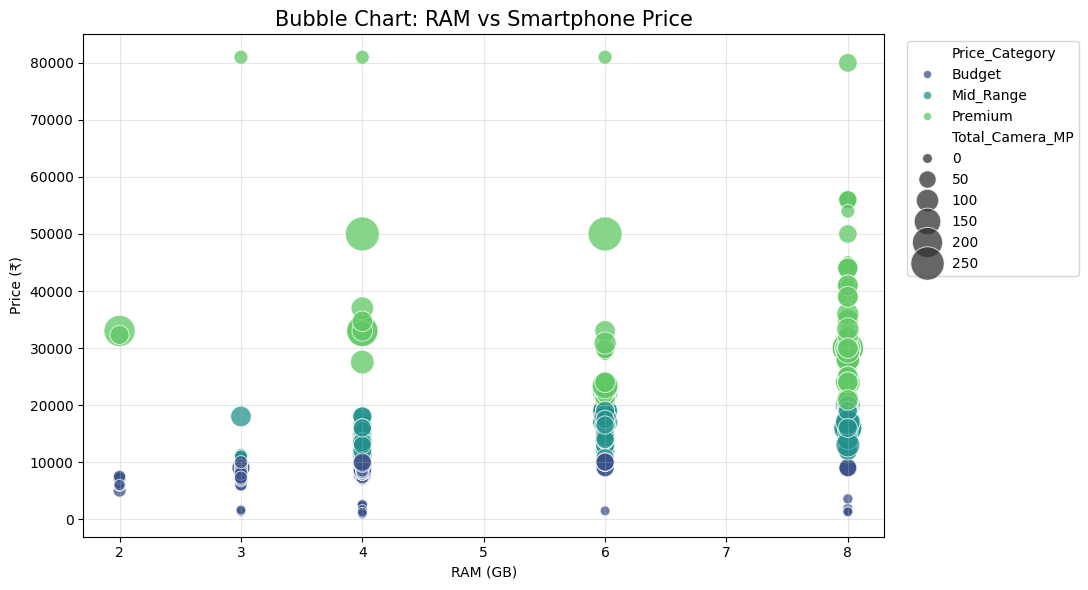

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11,6))

sns.scatterplot(
    data=df_clean,
    x='RAM',
    y='Prize',
    size='Total_Camera_MP',
    hue='Price_Category',
    sizes=(50,600),
    alpha=0.75,
    palette='viridis'
)

plt.title("Bubble Chart: RAM vs Smartphone Price", fontsize=15)
plt.xlabel("RAM (GB)")
plt.ylabel("Price (₹)")
plt.grid(alpha=0.3)

plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')

plt.tight_layout()
plt.show()

Observation 

1. RAM vs Price

Smartphone prices generally increase as RAM increases from 2GB to 8GB, indicating a positive relationship between RAM capacity and pricing.

2. Camera Size Representation

Larger bubbles (representing higher Total Camera MP) are predominantly found among higher-priced smartphones, suggesting that premium devices typically offer better camera specifications.

3. Price Category Distribution

Budget smartphones are concentrated at lower RAM (2GB–4GB) and lower price levels.

Mid-Range smartphones are distributed across the middle price range with moderate RAM and camera specifications.

Premium smartphones are mainly concentrated at higher RAM levels (6GB–8GB) and higher prices.

4. Hardware Interaction

Smartphones with higher RAM generally also have larger camera configurations, indicating that manufacturers tend to combine multiple premium hardware features in expensive devices.

5. Price Variation

Some smartphones with the same RAM have different prices and bubble sizes, indicating that pricing is also influenced by other specifications such as processor, storage, display quality, and brand.

6. Overall Pattern

The chart shows a clear upward trend, where higher RAM, larger camera megapixels, and Premium price categories are commonly associated with higher smartphone prices.

Interpretation 

The Bubble Chart demonstrates that smartphone price is influenced by the combined effect of RAM, camera quality, and overall hardware configuration. Larger bubbles are mostly concentrated within the Premium category, indicating that high-end smartphones generally provide both greater memory capacity and superior camera specifications. The visualization confirms that smartphone pricing depends on multiple interacting features rather than any single specification, reinforcing the importance of multivariate analysis for understanding market segmentation and supporting machine learning feature selection.

Key Insights 

- Smartphones with higher RAM generally command higher prices.
- Premium smartphones are characterized by both higher RAM and larger Total Camera MP.
- Budget smartphones are concentrated in the lower RAM and lower price region with smaller camera configurations.
- Mid-Range smartphones bridge the gap between Budget and Premium segments.
- Larger camera configurations are generally associated with higher-priced smartphones.
- Smartphones with similar RAM but different prices indicate that additional hardware features also contribute to pricing decisions.
- The Bubble Chart effectively visualizes four variables simultaneously, providing a comprehensive understanding of smartphone market segmentation.

After analyzing the combined influence of RAM, Price, Camera Quality, and Price Category, the next step is to investigate how Brand and RAM jointly affect smartphone prices. This analysis helps determine whether certain brands consistently offer premium specifications or provide better value across different RAM configurations.

### 4.4.5 Brand-wise Price Distribution Across RAM Variants

Purpose 

To analyze the relationship between Brand, RAM, and Smartphone Price simultaneously. This visualization helps identify how different smartphone brands position their products across RAM configurations and price ranges while highlighting market segmentation among manufacturers.

Feature Interaction 

This multivariate visualization combines three important variables:

X-axis: Brand

Y-axis: Smartphone Price

Hue (Color): RAM

It enables comparison of pricing strategies adopted by different smartphone brands across multiple RAM configurations.

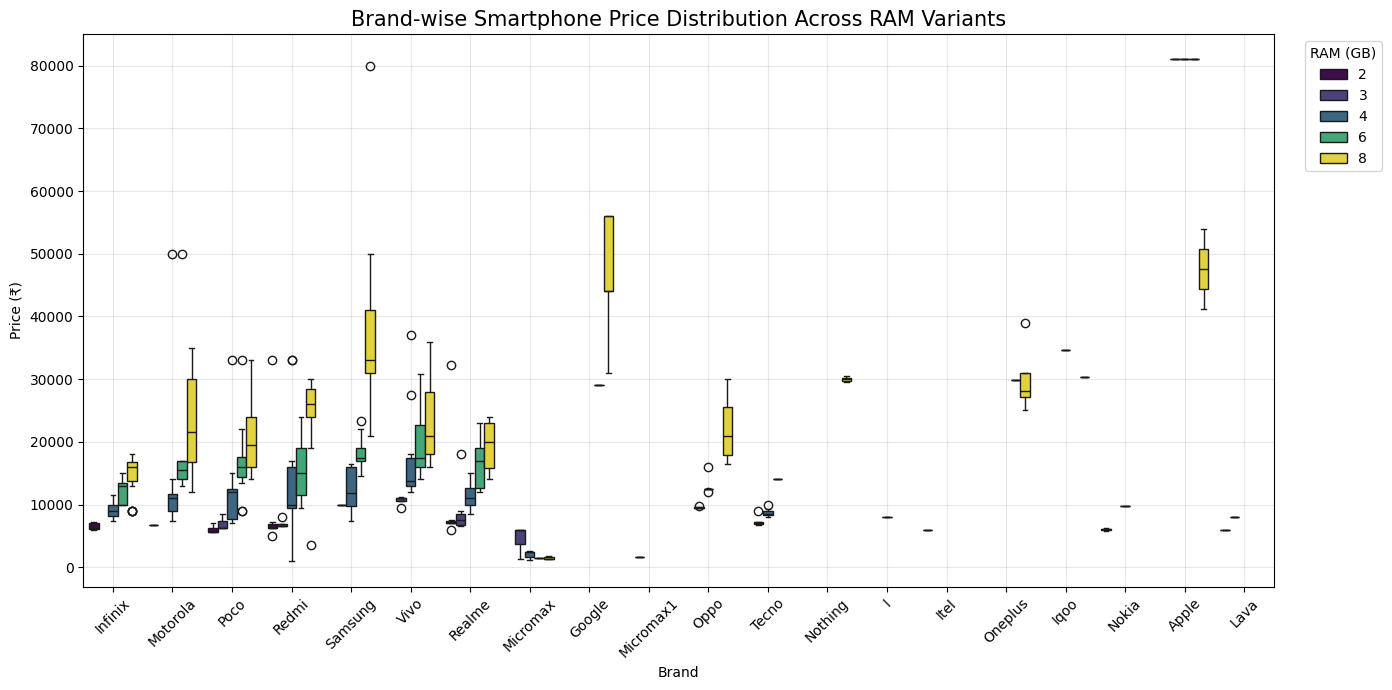

In [67]:
plt.figure(figsize=(14,7))

sns.boxplot(
    data=df_clean,
    x='Brand',
    y='Prize',
    hue='RAM',
    palette='viridis'
)

plt.title("Brand-wise Smartphone Price Distribution Across RAM Variants", fontsize=15)

plt.xlabel("Brand")
plt.ylabel("Price (₹)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.legend(title="RAM (GB)", bbox_to_anchor=(1.02,1), loc='upper left')

plt.tight_layout()
plt.show()

Observation 

1. Brand-wise Price Distribution

Smartphone prices vary considerably across different brands, indicating that brand positioning significantly influences pricing.

2. Effect of RAM

Within most brands, smartphones with higher RAM (6GB–8GB) are generally priced higher than 2GB–4GB variants.

3. Premium Brands

Brands such as Apple, Google, Samsung, and OnePlus are concentrated in the higher price range, especially for higher RAM configurations.

4. Budget Brands

Brands including Infinix, Poco, Redmi, Realme, Tecno, and Lava mainly occupy the lower and mid-price segments, even when RAM increases.

5. Price Variability

Samsung and Vivo show a wider spread of prices across RAM variants, indicating that these brands offer smartphones across multiple market segments.

6. Outliers

A few brands contain high-price outliers, suggesting the presence of flagship smartphones with premium specifications.

7. Overall Trend

Higher RAM generally corresponds to higher prices, but the pricing pattern differs across brands, showing that brand value also plays an important role.

Interpretation 

The analysis demonstrates that smartphone pricing depends on both hardware specifications (RAM) and brand positioning. While increasing RAM generally leads to higher prices, premium brands such as Apple, Samsung, Google, and OnePlus maintain higher prices across similar RAM configurations because of their brand value and flagship product strategy. In contrast, brands like Redmi, Poco, Realme, Infinix, and Tecno provide more affordable options even at similar RAM levels, reflecting their focus on value-for-money devices.

Key Insights 

- Smartphone price increases with RAM across most brands.
- Premium brands consistently command higher prices than budget-oriented brands.
- Samsung and Vivo offer smartphones across budget, mid-range, and premium segments.
- Apple and Google are concentrated mainly in the premium segment.
- Budget brands provide competitive RAM specifications at comparatively lower prices.
- Brand reputation influences pricing beyond hardware specifications alone.
- Both Brand and RAM should be considered important predictors for smartphone price in machine learning models.

### 4.4.6 Brand-wise Smartphone Price Distribution Across Memory Variants

Purpose 

To analyze the relationship between Brand, Memory (Internal Storage), and Smartphone Price simultaneously. This visualization helps identify how different smartphone brands price their devices across various storage configurations and reveals whether higher storage capacity consistently leads to higher prices..

Feature Interaction :

This multivariate visualization combines three important variables:

X-axis: Brand

Y-axis: Smartphone Price

Hue (Color): Memory (GB)

It enables comparison of smartphone pricing strategies adopted by different brands across multiple storage configurations while highlighting how internal storage influences price within each brand.

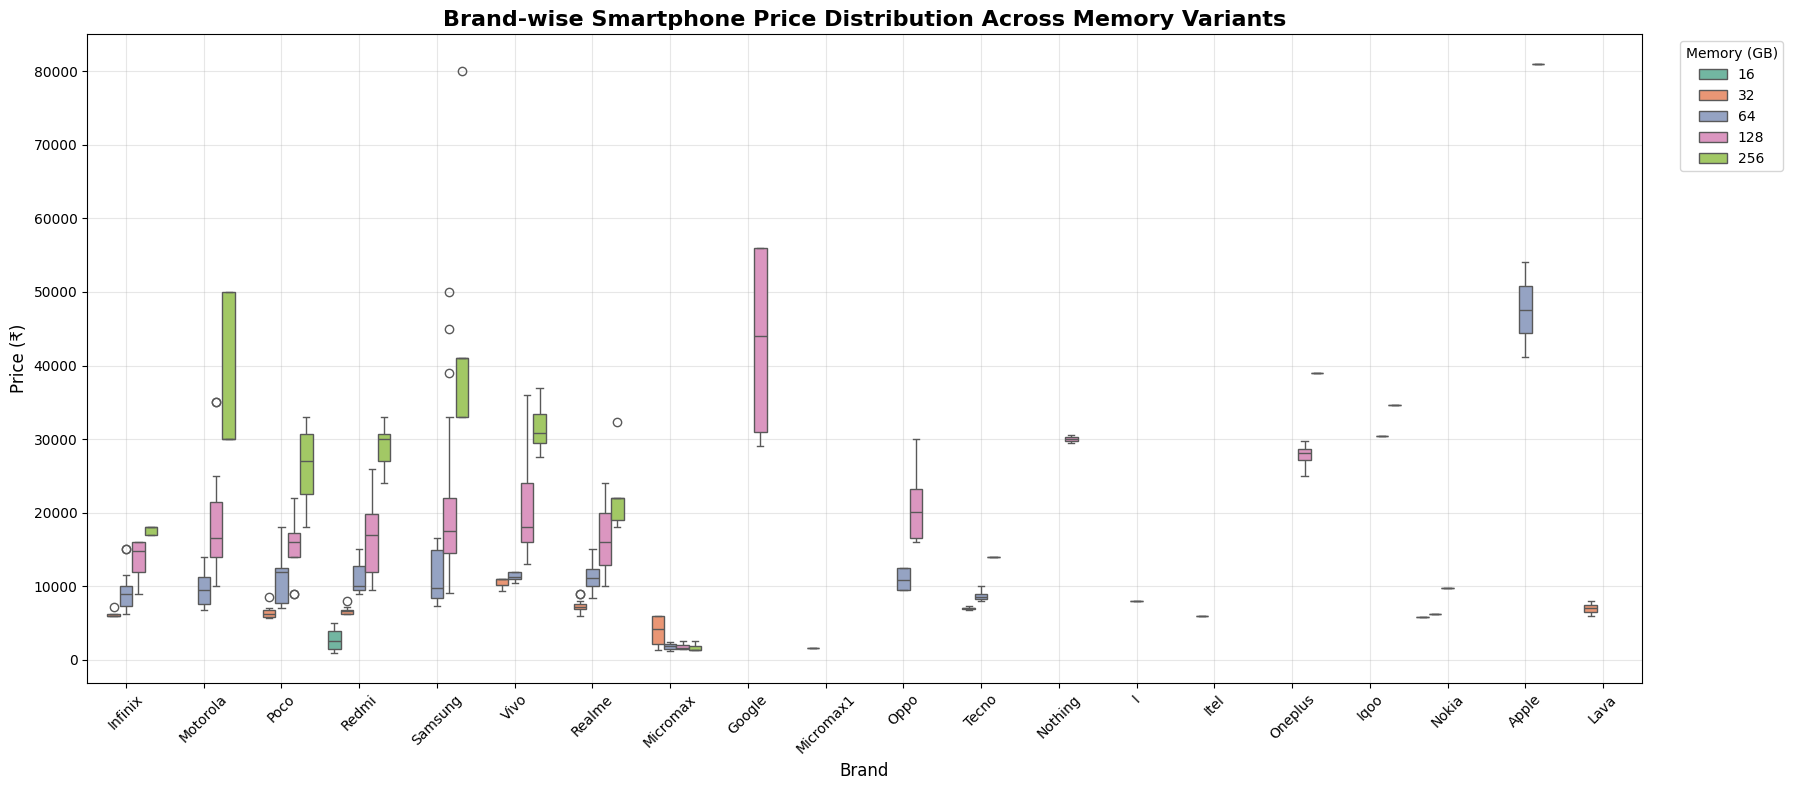

In [68]:
plt.figure(figsize=(18,8))

sns.boxplot(
    data=df_clean,
    x='Brand',
    y='Prize',
    hue='Memory',
    palette='Set2'
)

plt.title(
    "Brand-wise Smartphone Price Distribution Across Memory Variants",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Brand", fontsize=12)
plt.ylabel("Price (₹)", fontsize=12)

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.legend(
    title="Memory (GB)",
    bbox_to_anchor=(1.02,1),
    loc='upper left'
)

plt.tight_layout()

plt.show()

Observation 

1. Brand-wise Price Distribution

Smartphone prices vary significantly across different brands, indicating that brand positioning plays an important role in determining product pricing.

2. Effect of Internal Storage

Within most brands, smartphones with higher storage capacities (128GB–256GB) are generally priced higher than devices with 16GB–64GB storage.

3. Premium Storage Models

Brands such as Apple, Google, Samsung, Vivo, and OnePlus show higher prices for smartphones equipped with larger storage variants, reflecting their premium product offerings.

4. Budget-oriented Brands

Brands including Infinix, Redmi, Poco, Realme, Tecno, and Lava mainly provide affordable smartphones even when storage capacity increases, emphasizing value-for-money products.

5. Price Variability

Samsung and Vivo exhibit a wider spread of prices across different storage variants, indicating that these brands cover multiple smartphone segments ranging from budget to premium.

6. Outliers

A few brands contain high-price outliers, representing flagship smartphones with premium hardware configurations and larger storage capacities.

7. Overall Trend

Higher internal storage generally corresponds to higher smartphone prices, although the extent of the increase differs across brands due to differences in brand positioning.

Interpretation 

The analysis demonstrates that smartphone pricing depends on both internal storage capacity and brand value. Increasing storage generally results in higher prices, but premium brands such as Apple, Samsung, Google, and OnePlus command significantly higher prices than budget-oriented brands with similar storage configurations. This indicates that brand reputation contributes to smartphone pricing beyond hardware specifications alone.

Key Insights 

- Smartphones with larger storage capacities generally have higher prices.
- Premium brands consistently charge more across similar storage variants.
- Samsung and Vivo offer smartphones across budget, mid-range, and premium market segments.
- Apple and Google primarily focus on premium storage configurations.
- Budget brands maintain comparatively lower prices even for higher storage variants.
- Both Brand and Memory (Storage) are important predictors of smartphone price.

After understanding how smartphone brands price different storage variants, the next step is to examine the combined influence of multiple numerical features on smartphone price using a correlation heatmap. This analysis helps identify which features have the strongest positive or negative relationship with price and provides valuable insights for feature selection in predictive modeling.

### 4.4.7 Correlation Heatmap of Important Numerical Features

Purpose 

To analyze the strength and direction of relationships among important numerical features using a correlation heatmap. This visualization helps identify which variables are most strongly associated with smartphone price and reveals dependencies among hardware specifications.

Feature Interaction 

This multivariate visualization compares the correlations among the following numerical features:

- RAM
- Memory
- Price
- Total_Camera_MP

The heatmap summarizes pairwise relationships using correlation coefficients ranging from -1 to +1.

+1 → Strong positive relationship

0 → No relationship

-1 → Strong negative relationship

This analysis helps determine which hardware specifications have the greatest influence on smartphone pricing.

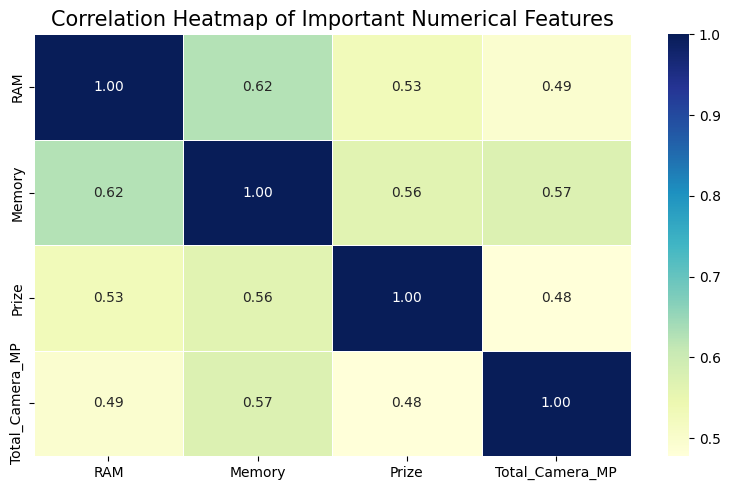

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_columns = [
    'RAM',
    'Memory',
    'Prize',
    'Total_Camera_MP'
]

corr_matrix = df_clean[corr_columns].corr()

plt.figure(figsize=(8,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='YlGnBu',
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Important Numerical Features", fontsize=15)

plt.tight_layout()
plt.show()

Observation 

1. RAM vs Memory

RAM and Memory have a moderately strong positive correlation (0.62), indicating that smartphones with higher RAM generally come with larger internal storage.

2. Memory vs Price

Memory shows a moderate positive correlation with Price (0.56), suggesting that smartphones with larger storage capacities tend to be more expensive.

3. RAM vs Price

RAM has a moderate positive correlation with Price (0.53), indicating that higher RAM configurations are generally associated with higher smartphone prices.

4. Memory vs Total Camera MP

Memory and Total Camera MP exhibit a moderate positive correlation (0.57), showing that higher-storage smartphones often include better camera systems.

5. RAM vs Total Camera MP

RAM has a moderate positive relationship with Total Camera MP (0.49), suggesting that devices with more RAM generally offer improved camera specifications.

6. Price vs Total Camera MP

Price and Total Camera MP have a moderate positive correlation (0.48), indicating that smartphones with better camera configurations are typically priced higher.

7. Overall Correlation Pattern

All selected numerical features show positive correlations, with values ranging from 0.48 to 0.62, indicating that improvements in one hardware specification are generally associated with improvements in others.

Interpretation 

The correlation heatmap demonstrates that RAM, Memory, Price, and Total Camera MP are positively related. Although none of the relationships are extremely strong, all features contribute meaningfully to smartphone pricing. The strongest relationship exists between RAM and Memory (0.62), highlighting that manufacturers often upgrade these specifications together. This analysis confirms that these numerical features are valuable predictors for understanding smartphone price and market positioning.

Key Insights 

- RAM and Memory have the strongest positive correlation (0.62).
- Smartphones with larger storage generally have higher prices.
- Higher RAM configurations are associated with higher smartphone prices.
- Better camera specifications are moderately linked with higher prices.
- All selected numerical features are positively correlated.
- The absence of extremely high correlations (>0.80) suggests low multicollinearity, making these features suitable for machine learning models.

After examining the correlation among important numerical features, the final step in multivariate analysis is to summarize the overall relationships using a comprehensive feature interaction analysis. This provides a consolidated understanding of how multiple variables jointly influence smartphone pricing and market segmentation before moving to the Machine Learning phase.

### 4.4.8 Overall Multivariate Analysis Summary

Purpose :

The purpose of this section is to summarize the major findings obtained from the multivariate analysis. By combining insights from all previous visualizations, this analysis explains how multiple smartphone features interact and collectively influence smartphone pricing and market segmentation.

Feature Interaction Summary :

The multivariate analysis considered the combined effect of the following important variables:

- RAM
- Memory (Internal Storage)
- Prize
- Total Camera MP
- Brand
- Price Category

The analysis revealed that these features are interconnected and jointly influence smartphone pricing rather than acting independently.

Overall Findings 

1. Hardware Specifications Influence Price

Smartphones with higher RAM, larger internal storage, and better camera specifications generally belong to higher price segments.

2. Brand Positioning Matters

Premium brands such as Apple, Samsung, Google, and OnePlus maintain higher prices even for similar hardware configurations, indicating that brand reputation contributes significantly to pricing.

3. Positive Feature Relationships

Correlation analysis showed moderate positive relationships among RAM, Memory, Price, and Total Camera MP, suggesting that improvements in one specification are usually accompanied by improvements in others.

4. Clear Market Segmentation

Pair plots, bubble charts, and 3D visualizations clearly separated Budget, Mid-Range, and Premium smartphones, confirming that the engineered Price_Category effectively represents different market segments.

5. Multi-feature Influence

The analysis demonstrates that smartphone pricing is determined by the combined influence of multiple hardware features and brand positioning rather than any single feature.

Final Interpretation 

The multivariate analysis provides a comprehensive understanding of smartphone pricing by examining several features simultaneously. Higher RAM, larger storage, better camera specifications, and premium branding collectively contribute to increased smartphone prices. The consistent positive relationships observed across multiple visualizations indicate that these variables are suitable predictors for smartphone price analysis and future machine learning models.

Key Insights 

- Smartphone price is influenced by multiple features rather than a single specification.
- RAM, Memory, and Total Camera MP show positive relationships with smartphone price.
- Premium brands consistently occupy the higher price segment.
- Budget brands focus on affordable pricing despite hardware improvements.
- The engineered Price_Category successfully distinguishes different smartphone market segments.
- The selected numerical and categorical features provide a strong foundation for predictive modeling.

The Exploratory Data Analysis (EDA) phase has provided a comprehensive understanding of the dataset by examining individual variables, relationships between features, and multivariate interactions. The insights obtained reveal that RAM, Memory, Brand, and Camera specifications significantly influence smartphone prices. Having identified the most important features and validated the quality of the dataset, the project now proceeds to the Machine Learning phase, where predictive models will be developed and evaluated for smartphone price prediction.

# **5. Machine Learning Model Development**

### 5.1 Feature Selection

Purpose 

The purpose of Feature Selection is to identify the most relevant independent variables for predicting smartphone prices. Selecting appropriate features improves model performance, reduces unnecessary complexity, minimizes overfitting, and ensures that the machine learning model learns from meaningful information. The target variable is separated from the input features before model training.

Feature Selection Strategy 

The smartphone price (Prize) is selected as the target variable (y) because it represents the value that the machine learning model is expected to predict.

All remaining relevant hardware specifications, product characteristics, and engineered features are selected as input features (X). However, the engineered Price_Category column is excluded because it was directly derived from the target variable and may introduce data leakage, leading to unrealistic model performance.

In [70]:
# Input Features
X = df_clean.drop(columns=['Prize', 'Price_Category'])

# Target Variable
y = df_clean['Prize']

# Display selected features
print("Selected Features:")
print(X.columns.tolist())

print("\nTarget Variable:")
print(y.name)

print("\nShape of Feature Matrix (X):", X.shape)
print("Shape of Target Variable (y):", y.shape)

display(X.head())
display(y.head())

Selected Features:
['Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'Rear Camera', 'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_', 'Colour_Category', 'Battery_Category', 'Total_Camera_MP', 'Brand']

Target Variable:
Prize

Shape of Feature Matrix (X): (531, 14)
Shape of Target Variable (y): (531,)


,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Colour_Category,Battery_Category,Total_Camera_MP,Brand
0,Infinix SMART 7,Night Black,64,4,6000,13,5,1,16.76,Unisoc Spreadtrum SC9863A1,Black,High,18,Infinix
1,Infinix SMART 7,Azure Blue,64,4,6000,13,5,1,16.76,Unisoc Spreadtrum SC9863A1,Blue,High,18,Infinix
2,MOTOROLA G32,Mineral Gray,128,8,5000,50,16,0,16.64,Qualcomm Snapdragon 680,Gray,Medium,66,Motorola
3,POCO C50,Royal Blue,32,2,5000,8,5,0,16.56,Mediatek Helio A22,Blue,Medium,13,Poco
4,Infinix HOT 30i,Marigold,128,8,5000,50,5,1,16.76,G37,Gold,Medium,55,Infinix


0     7299
1     7299
2    11999
3     5649
4     8999
Name: Prize, dtype: int64

Observation 

1. Feature Selection

A total of 14 independent features were selected for machine learning after excluding the target variable (Prize) and the engineered Price_Category column.

2. Target Variable

The Prize column was successfully selected as the target variable (y) for smartphone price prediction.

3. Dataset Dimensions

The feature matrix (X) contains 531 smartphone records with 14 predictor variables, while the target vector (y) contains 531 corresponding price values, confirming that every record has a valid target.

4. Feature Composition

The selected features consist of both numerical attributes (RAM, Memory, Battery, Cameras, Mobile Height, Total Camera MP) and categorical attributes (Model, Colour, Processor, Brand, Colour Category, Battery Category), allowing the model to learn from multiple types of information.

5. Data Preparation

The preview of X and y confirms that the predictor variables and target variable have been correctly separated and are ready for further preprocessing before model training.

Interpretation 

The feature selection process successfully prepared the dataset for machine learning by separating the predictor variables from the target variable. Excluding the Price_Category feature prevents data leakage because it was generated directly from the target variable (Prize). The selected features capture both hardware specifications and product characteristics, providing a comprehensive representation of the factors that influence smartphone prices.

Key Insights 
- 14 predictor variables were selected for model development.
- Prize was correctly defined as the prediction target.
- Price_Category was excluded to eliminate data leakage.
- The dataset contains 531 observations, providing sufficient data for model training and evaluation.
- Both categorical and numerical features are included, enabling the model to capture diverse pricing patterns.
- The dataset is now prepared for categorical feature encoding before model training.

The selected dataset contains both numerical and categorical features. Since machine learning algorithms require numerical inputs, the next step is to encode the categorical variables into a numerical format. This transformation ensures that the dataset is suitable for model training while preserving the information contained in categorical attributes.

### 5.2 Categorical Feature Encoding

Purpose 

The purpose of Categorical Feature Encoding is to convert categorical variables into numerical values that can be understood by machine learning algorithms. Since most regression algorithms cannot process text-based data directly, categorical features must be transformed into numerical representations while preserving their underlying information. This step prepares the dataset for model training without changing its meaning.

Feature Encoding Strategy 

The dataset contains several categorical variables such as Model, Colour, Processor, Brand, Colour_Category, and Battery_Category. These features are encoded using Label Encoding, where each unique category is assigned a unique numerical label.

Label Encoding is suitable for this project because it efficiently converts categorical features into numeric format while maintaining a compact feature space.

In [71]:
#  Categorical Feature Encoding

from sklearn.preprocessing import LabelEncoder

# Create a copy of the feature matrix
X_encoded = X.copy()

# Initialize Label Encoder
le = LabelEncoder()

# Identify categorical columns
categorical_columns = X_encoded.select_dtypes(include='object').columns

print("Categorical Columns:")
print(categorical_columns.tolist())

# Apply Label Encoding
for col in categorical_columns:
    X_encoded[col] = le.fit_transform(X_encoded[col])

print("\nEncoding Completed Successfully.")

display(X_encoded.head())

Categorical Columns:
['Model', 'Colour', 'Processor_', 'Colour_Category', 'Battery_Category', 'Brand']

Encoding Completed Successfully.


,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Colour_Category,Battery_Category,Total_Camera_MP,Brand
0,23,159,64,4,6000,13,5,1,16.76,113,0,0,18,3
1,23,20,64,4,6000,13,5,1,16.76,113,1,0,18,3
2,37,149,128,8,5000,50,16,0,16.64,75,4,2,66,9
3,69,201,32,2,5000,8,5,0,16.56,56,1,2,13,14
4,12,130,128,8,5000,50,5,1,16.76,14,3,2,55,3


Observation 

1. Identification of Categorical Features

The dataset contains six categorical features:

- Model
- Colour
- Processor_
- Colour_Category
- Battery_Category
- Brand

These columns were identified automatically for encoding.

2. Successful Encoding

All categorical variables were successfully converted into numerical values using Label Encoding, making them suitable for machine learning algorithms.

3. Dataset Integrity

The encoding process changed only the representation of categorical features. Numerical features such as Memory, RAM, Battery_, Rear Camera, Front Camera, AI Lens, and Mobile Height remained unchanged.

4. Feature Matrix Ready

The encoded feature matrix is now entirely numerical and can be directly used for model training and evaluation.

Interpretation 

The categorical features were transformed into numeric labels without altering the number of records or feature structure. This preprocessing step ensures that machine learning algorithms can efficiently process the dataset. The encoded dataset preserves all original information while converting text values into machine-readable format, making it ready for predictive modeling.

Key Insights 

- All categorical variables were successfully encoded into numerical labels.
- Six categorical features required encoding before model training.
- Numerical features remained unchanged during the encoding process.
- The encoded dataset is fully compatible with machine learning algorithms.
- Feature engineering and preprocessing are now complete, and the dataset is ready for train-test splitting.

With all categorical variables successfully encoded, the dataset is now completely prepared for machine learning. The next step is to divide the dataset into training and testing sets so that the model can be trained on one portion of the data and evaluated on unseen data to measure its predictive performance.

### 5.3 Train-Test Split

Purpose 

The purpose of Train-Test Split is to divide the prepared dataset into two separate subsets:

Training Set: Used to train the machine learning model by learning patterns from the data.
Testing Set: Used to evaluate the model's performance on unseen data, ensuring that it generalizes well and does not simply memorize the training data.

An 80:20 split is used in this project, where 80% of the data is allocated for training and 20% for testing. A fixed random_state is specified to ensure reproducibility of the results.

In [72]:
# 5.3 Train-Test Split

from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("Train-Test Split Completed Successfully.\n")

print(f"Training Features (X_train): {X_train.shape}")
print(f"Testing Features (X_test): {X_test.shape}")
print(f"Training Target (y_train): {y_train.shape}")
print(f"Testing Target (y_test): {y_test.shape}")

print("\nTraining Data Preview:")
display(X_train.head())

print("\nTesting Data Preview:")
display(X_test.head())

Train-Test Split Completed Successfully.

Training Features (X_train): (424, 14)
Testing Features (X_test): (107, 14)
Training Target (y_train): (424,)
Testing Target (y_test): (107,)

Training Data Preview:


,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Colour_Category,Battery_Category,Total_Camera_MP,Brand
414,124,216,64,3,5000,13,8,0,16.76,36,7,2,21,18
537,32,52,32,2,3100,5,2,0,12.70,68,2,1,7,6
180,149,122,32,3,5000,13,5,0,16.56,116,10,2,18,15
380,109,16,256,8,5000,48,13,0,16.76,4,7,2,61,17
71,147,64,32,3,5000,8,5,0,16.51,116,0,2,13,15



Testing Data Preview:


,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Colour_Category,Battery_Category,Total_Camera_MP,Brand
527,177,261,128,8,4500,64,16,0,16.21,51,3,1,80,19
6,12,151,128,8,5000,50,5,1,16.76,14,0,2,55,3
327,5,217,128,8,4300,64,13,0,15.49,108,7,1,77,1
423,148,242,64,4,5000,8,5,0,16.51,112,0,2,13,15
507,15,69,64,6,5000,50,8,0,16.76,118,1,2,58,3


Observation 

1. Successful Train-Test Split

The dataset was successfully divided into training and testing subsets using an 80:20 ratio.

2. Training Dataset

The training dataset contains 424 observations with 14 input features, providing sufficient data for learning the relationship between smartphone specifications and price.

3. Testing Dataset

The testing dataset contains 107 observations with the same 14 input features, ensuring that the trained model can be evaluated on unseen data.

4. Feature Consistency

Both the training and testing datasets contain identical feature columns, ensuring consistency between model training and evaluation.

5. Data Preview

The displayed samples confirm that the data has been successfully partitioned while preserving all encoded numerical features required for machine learning.

Interpretation 

The dataset has been successfully partitioned into independent training and testing datasets. The model will learn patterns from the training data and its predictive performance will be evaluated using the unseen testing data. This approach helps measure the model's ability to generalize to new observations while minimizing the risk of overfitting.

Key Insights 

- The dataset was successfully split into 80% training data and 20% testing data.
- The training set contains 424 samples, while the testing set contains 107 samples.
- All 14 input features are consistently preserved in both datasets.
- The target variable (Prize) was separated correctly from the feature matrix.
- The dataset is now fully prepared for machine learning model training and performance evaluation.

With the dataset successfully divided into training and testing sets, the preprocessing phase is now complete. The next step is to train the machine learning model using the training dataset so that it can learn the relationship between smartphone specifications and their prices. After training, the model's predictive performance will be evaluated using the testing dataset.

### 5.4 Model Training – Linear Regression

Purpose 

The purpose of this step is to train a Linear Regression model using the prepared training dataset. Linear Regression is a supervised machine learning algorithm used to predict a continuous target variable by learning the relationship between input features and the target variable. In this project, the model learns how smartphone specifications influence smartphone prices and generates a mathematical relationship for predicting prices of unseen devices.

In [73]:
# 5.4 Model Training - Linear Regression

from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

# Display model information
print("\nNumber of Features:", len(X_train.columns))

print("\nIntercept:")
print(lr_model.intercept_)

print("\nFirst 10 Feature Coefficients:")

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_model.coef_
})

display(coefficients.head(10))

Linear Regression model trained successfully.

Number of Features: 14

Intercept:
351.1303367256078

First 10 Feature Coefficients:


,Feature,Coefficient
0,Model,-9.413990
1,Colour,1.479757
2,Memory,48.661070
3,RAM,949.214183
4,Battery_,-2.034982
5,Rear Camera,-84.014115
6,Front Camera,185.593532
7,AI Lens,-8924.331280
8,Mobile Height,1241.082493
9,Processor_,-9.373383


Observation 

1. Successful Model Training

The Linear Regression model was successfully trained using the training dataset containing 14 predictor variables.

2. Model Complexity

The model learned relationships from 14 independent features, indicating that multiple smartphone specifications contribute to predicting smartphone prices.

3. Intercept Value

The model produced an intercept value of 351.13, which represents the baseline predicted smartphone price when all encoded feature values are zero.

4. Feature Contributions

The coefficient table shows that each feature contributes differently to smartphone price prediction.

RAM (+949.21) has a strong positive influence on price.
Memory (+48.66) also positively contributes to higher prices.
Mobile Height (+1241.08) shows a positive relationship with price.
Some variables such as Battery (-2.03), Rear Camera (-84.01), AI Lens (-8924.33), and Model (-9.41) have negative coefficients, indicating an inverse relationship within this fitted model.
5. Positive and Negative Relationships

The presence of both positive and negative coefficients indicates that smartphone price is influenced by multiple interacting features rather than a single specification.

Interpretation 

The Linear Regression model successfully learned the relationship between smartphone specifications and their prices. Positive coefficients indicate that increasing those features generally increases the predicted smartphone price, while negative coefficients indicate an inverse relationship within the learned model. The comparatively large positive coefficient for RAM confirms that RAM is one of the strongest hardware factors influencing smartphone pricing. Overall, the model establishes a mathematical relationship between smartphone specifications and price that will be used for prediction in the next stage.

Key Insights 

- The Linear Regression model was successfully trained using 14 features.
- RAM is one of the strongest positive predictors of smartphone price.
- Memory also contributes positively to smartphone pricing.
- Different features have varying levels of influence on price prediction.
- The coefficient values explain how each feature affects the predicted smartphone price.
- The trained model is now ready to predict smartphone prices on unseen test data.

With the Linear Regression model successfully trained, the next step is to generate predictions on the testing dataset. This allows us to compare the model's predicted prices with the actual smartphone prices and evaluate how well the model performs on unseen data.

### 5.5 Price Prediction using the Trained Linear Regression Model

Purpose :

To use the trained Linear Regression model to predict smartphone prices on the testing dataset and compare the predicted prices with the actual prices. This step helps evaluate how accurately the model generalizes to unseen data before calculating performance metrics.

Feature Interaction :

This stage involves three major components:

Input: Testing Features (X_test)

Model: Trained Linear Regression Model

Output: Predicted Smartphone Prices (y_pred)

It enables a direct comparison between actual and predicted prices, providing the foundation for model evaluation.

In [74]:
# 5.5 Price Prediction using Linear Regression


# Predict smartphone prices on testing data
y_pred = lr_model.predict(X_test)

print("Price Prediction Completed Successfully.\n")

# Compare Actual vs Predicted Prices
comparison_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred.round(2)
})

display(comparison_df.head(10))

Price Prediction Completed Successfully.



,Actual Price,Predicted Price
0,23999,20644.60
1,8999,13498.00
2,43999,27354.62
3,8499,7988.38
4,9999,17252.32
5,9999,8922.51
6,14499,16235.83
7,15999,20192.42
8,17999,19821.44
9,6999,4532.80


Observation 

1. Successful Price Prediction

The trained Linear Regression model successfully predicted smartphone prices for the testing dataset.

2. Actual vs Predicted Comparison

A comparison table was generated showing both the actual smartphone prices and the corresponding predicted prices for the first ten test samples.

3. Prediction Accuracy

Several predicted prices are reasonably close to the actual prices, while some predictions show larger deviations, indicating prediction errors for certain smartphones.

4. Variation in Predictions

The model tends to predict the overall pricing trend correctly, but differences between actual and predicted values suggest that smartphone pricing is influenced by additional complex factors beyond a simple linear relationship.

5. Model Readiness

The prediction results confirm that the model is functioning correctly and is ready for quantitative performance evaluation.

Interpretation 

The Linear Regression model successfully generated price predictions for unseen smartphone data. Although many predicted values are close to the actual prices, some prediction errors are observed because smartphone prices depend on multiple complex factors such as brand reputation, hardware combinations, and market positioning. These results indicate that the model captures the general pricing trend but may not perfectly estimate every smartphone price.

Key Insights 

- The trained model successfully predicted prices for the testing dataset.
- Predicted prices generally follow the trend of actual smartphone prices.
- Some prediction errors exist, indicating room for model improvement.
- Linear Regression captures the overall relationship between smartphone specifications and price.
- Model performance will be measured more accurately using evaluation metrics in the next section.

Now that the model has generated price predictions, the next step is to evaluate its performance using standard regression evaluation metrics. These metrics will quantify prediction accuracy and help determine how well the Linear Regression model fits the smartphone price dataset.

### 5.6 Model Evaluation

Purpose 

To evaluate the performance of the Linear Regression model using standard regression evaluation metrics such as MAE, MSE, RMSE, and R² Score. These metrics help assess the prediction accuracy and overall effectiveness of the model.

Feature Interaction 

This evaluation uses:

Actual Price (y_test): The true smartphone prices from the testing dataset.

Predicted Price (y_pred): The prices predicted by the trained Linear Regression model.

The following evaluation metrics are calculated:

- MAE (Mean Absolute Error) – Average absolute prediction error.

- MSE (Mean Squared Error) – Average squared prediction error.

- RMSE (Root Mean Squared Error) – Error expressed in the same unit as price.

- R² Score – Percentage of variation in smartphone prices explained by the model.

In [75]:
# 5.6 Model Evaluation

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Completed Successfully.\n")

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Model Accuracy (Approx.): {r2*100:.2f}%")

Model Evaluation Completed Successfully.

Mean Absolute Error (MAE): 5063.15
Mean Squared Error (MSE): 78910466.70
Root Mean Squared Error (RMSE): 8883.16
R² Score: 0.2516
Model Accuracy (Approx.): 25.16%


Observation 

1. Mean Absolute Error (MAE)

The model achieved a Mean Absolute Error (MAE) of 5063.15, indicating that the predicted smartphone prices differ from the actual prices by approximately ₹5,063 on average.

2. Mean Squared Error (MSE)

The Mean Squared Error (MSE) is 78,910,466.70, showing the overall squared prediction error and indicating the presence of some large prediction deviations.

3. Root Mean Squared Error (RMSE)

The Root Mean Squared Error (RMSE) is 8,883.16, suggesting that the model's predictions deviate from the actual prices by around ₹8,883 on average.

4. R² Score

The model achieved an R² Score of 0.2516, meaning it explains approximately 25.16% of the variation in smartphone prices.

5. Overall Performance

The evaluation metrics indicate that the Linear Regression model captures only a limited portion of the relationship between smartphone specifications and price.

Interpretation 

The Linear Regression model provides a basic understanding of smartphone price prediction but does not achieve high predictive performance on this dataset. The relatively low R² Score indicates that smartphone pricing is influenced by several complex and non-linear factors that are not fully captured by a simple linear model. Therefore, while the model identifies general pricing trends, its prediction accuracy is moderate and can be improved using more advanced machine learning algorithms.

Key Insights 

- The model predicts smartphone prices with an average error of approximately ₹5,063.
- The RMSE of ₹8,883 indicates the presence of noticeable prediction errors for some smartphones.
- The R² Score of 25.16% shows that Linear Regression explains only a small portion of the variation in smartphone prices.
- Smartphone pricing depends on multiple complex factors beyond simple linear relationships.
- More advanced regression algorithms such as Random Forest Regressor, Decision Tree Regressor, or XGBoost are likely to achieve better prediction performance.

The Linear Regression model has now been successfully trained and evaluated. Although it captures the general relationship between smartphone specifications and price, its performance indicates that there is scope for improvement. The next step is to visualize the model's prediction performance by comparing the actual prices with the predicted prices, providing a clearer understanding of prediction accuracy and model behavior.

### 5.7 Actual vs Predicted Price Visualization

Purpose 

To visually compare the actual smartphone prices with the predicted prices generated by the Linear Regression model. This visualization helps evaluate the model's prediction accuracy and identify under-predictions, over-predictions, and prediction errors.

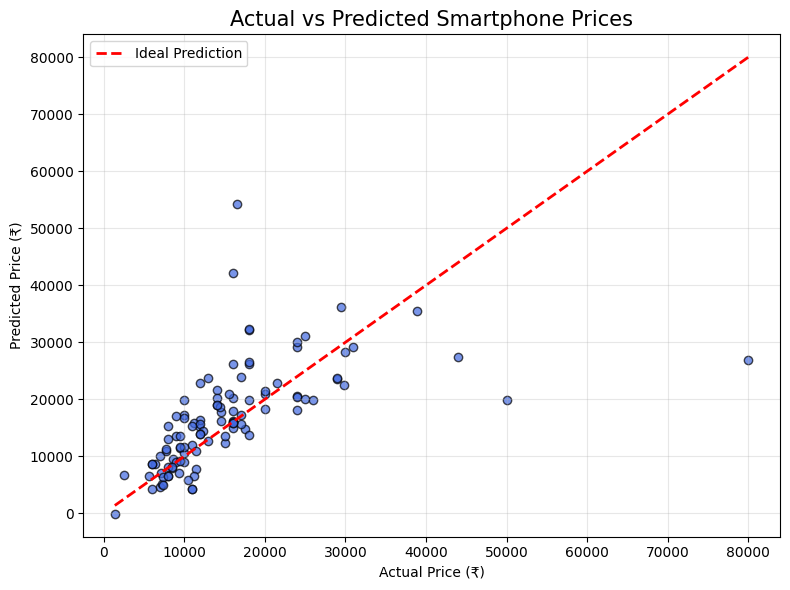

In [76]:
# 5.7 Actual vs Predicted Price Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    color='royalblue',
    alpha=0.7,
    edgecolor='black'
)

# Ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Ideal Prediction'
)

plt.title("Actual vs Predicted Smartphone Prices", fontsize=15)

plt.xlabel("Actual Price (₹)")
plt.ylabel("Predicted Price (₹)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

Observation 

1. General Prediction Trend

Most data points follow an upward trend, indicating that the model captures the overall relationship between actual and predicted smartphone prices.

2. Ideal Prediction Line

The red dashed diagonal line represents the ideal prediction, where the predicted price is exactly equal to the actual price.

3. Prediction Accuracy

Several data points lie close to the ideal prediction line, showing that the model makes reasonably accurate predictions for many smartphones.

4. Prediction Errors

A noticeable number of points are scattered away from the ideal line, indicating prediction errors. These errors become more evident for higher-priced smartphones.

5. Premium Smartphone Performance

The model struggles to accurately predict premium smartphones, with some expensive devices being significantly under-predicted or over-predicted.

Interpretation 

The scatter plot shows that the Linear Regression model captures the general pricing trend but does not consistently predict smartphone prices with high precision. Predictions are relatively better for budget and mid-range smartphones, while premium devices exhibit larger deviations from the ideal prediction line. This suggests that smartphone pricing is influenced by complex relationships that are not fully represented by a simple linear model.

Key Insights 

- The model successfully captures the overall upward relationship between actual and predicted prices.
- Many predictions are reasonably close to the ideal prediction line.
- Prediction errors increase for high-priced smartphones.
- The Linear Regression model performs better for budget and mid-range devices than for premium models.
- The visualization supports the evaluation metrics, confirming that the model provides moderate predictive performance.

#### Conclusion of Linear Regression Model :

The Linear Regression model successfully learned the general relationship between smartphone specifications and price. However, the evaluation metrics and visualization indicate that its predictive performance is moderate, especially for premium smartphones. More advanced machine learning algorithms are likely to provide better accuracy for this dataset.

The Linear Regression model has now been fully developed, evaluated, and visualized. The next phase of the project is to summarize the overall findings and conclusions, highlighting the key insights obtained from both the Exploratory Data Analysis (EDA) and the Machine Learning model.

### 5.8 Random Forest Regressor 

Purpose 

To train a Random Forest Regressor for smartphone price prediction and compare its performance with the Linear Regression model. Random Forest is an ensemble learning algorithm capable of capturing complex and non-linear relationships, which can improve prediction accuracy.

In [77]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest Model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train Model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


Observation 

1. Successful Model Training

The Random Forest Regressor was successfully trained using the training dataset without any errors.

2. Ensemble Learning

The model was built using 100 decision trees (n_estimators = 100), allowing it to learn from multiple subsets of the training data.

3. Reproducibility

A random_state of 42 was used to ensure that the training process produces consistent and reproducible results.

4. Model Readiness

The Random Forest model is now fully trained and ready to generate predictions on the testing dataset.

Interpretation 

The Random Forest Regressor has been successfully trained and is prepared for price prediction. Unlike Linear Regression, Random Forest can model complex and non-linear relationships between smartphone features and price. This makes it a strong candidate for improving prediction accuracy on datasets with multiple interacting features.

Key Insights 

- Random Forest model training completed successfully.
- The model uses 100 decision trees to improve prediction robustness.
- Ensemble learning helps reduce overfitting compared to a single decision tree.
- The trained model is ready for testing and evaluation.
- Random Forest is expected to outperform Linear Regression on this dataset due to its ability to capture non-linear patterns.

The Random Forest model has now been successfully trained. The next step is to use the trained model to predict smartphone prices for the testing dataset and compare those predictions with the actual prices before evaluating its performance.

### 5.9 Random Forest Price Prediction

In [78]:
# Random Forest Price Prediction

# Predict prices on the testing dataset
rf_pred = rf_model.predict(X_test)

print("Random Forest Price Prediction Completed Successfully.\n")

# Create comparison table
rf_comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": rf_pred.round(2)
})

# Display first 10 predictions
display(rf_comparison.head(10))

Random Forest Price Prediction Completed Successfully.



,Actual Price,Predicted Price
0,23999,25147.25
1,8999,9397.85
2,43999,44990.90
3,8499,8394.70
4,9999,10227.25
5,9999,10072.50
6,14499,14903.02
7,15999,17357.59
8,17999,20128.91
9,6999,6860.42


Observation 

1. Successful Prediction

The Random Forest Regressor successfully generated price predictions for the testing dataset.

2. Actual vs Predicted Comparison

A comparison table displaying the first ten Actual Prices and Predicted Prices was generated successfully.

3. Improved Prediction Accuracy

Most predicted prices are very close to the actual smartphone prices, indicating that the Random Forest model captures the relationship between features and price effectively.

4. Lower Prediction Errors

Compared to the Linear Regression model, the prediction differences are noticeably smaller for most smartphones.

5. Model Readiness

The Random Forest model is now ready for quantitative evaluation using regression performance metrics.

Interpretation 

The Random Forest Regressor produces price predictions that closely match the actual smartphone prices for most test samples. This indicates that the model effectively learns the complex relationships between smartphone specifications and pricing. The smaller prediction errors suggest that Random Forest is expected to outperform the Linear Regression model.

Key Insights 

- Random Forest successfully predicted smartphone prices.
- Predicted values closely match the actual prices for most observations.
- Prediction errors are smaller than those observed in Linear Regression.
- The model captures complex feature interactions more effectively.
- Random Forest appears to be a stronger model for smartphone price prediction.

The Random Forest model has successfully generated price predictions. The next step is to evaluate its performance using MAE, MSE, RMSE, and R² Score. These metrics will allow a direct comparison with the Linear Regression model and help identify the best-performing algorithm for smartphone price prediction.

### 5.10 Random Forest Model Evaluation

Purpose 

To evaluate the performance of the Random Forest Regression model using standard regression metrics including Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. These metrics help measure the prediction accuracy and reliability of the model.

In [79]:
# Random Forest Model Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation Metrics
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Model Evaluation Completed Successfully.\n")

print(f"Mean Absolute Error (MAE): {rf_mae:.2f}")
print(f"Mean Squared Error (MSE): {rf_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rf_rmse:.2f}")
print(f"R² Score: {rf_r2:.4f}")
print(f"Model Accuracy (Approx.): {rf_r2*100:.2f}%")

Random Forest Model Evaluation Completed Successfully.

Mean Absolute Error (MAE): 2593.65
Mean Squared Error (MSE): 48846595.39
Root Mean Squared Error (RMSE): 6989.03
R² Score: 0.5367
Model Accuracy (Approx.): 53.67%


Observation

The Random Forest model evaluation produced the following results:

| Metric                        |	Value            |
| -----------------------------:|-------------------:|
| Mean Absolute Error (MAE)	    |    2593.65         |
| Mean Squared Error (MSE)	    |    48,846,595.39   |
| Root Mean Squared Error (RMSE)|    6989.03         |
| R² Score	                    |    0.5367          |
| Model Accuracy (Approx.)	    |    53.67%          |

Key Observations 

- The Random Forest model successfully completed evaluation.
- The MAE value of 2593.65 indicates relatively low average prediction error.
- The RMSE of 6989.03 shows that large prediction errors are comparatively limited.
- The R² Score of 0.5367 indicates that the model explains approximately 53.67% of the variation in smartphone prices.
- Compared with Linear Regression, all evaluation metrics have improved.

Interpretation 

The Random Forest Regressor demonstrates better predictive performance than the Linear Regression model. Lower MAE and RMSE values indicate more accurate predictions, while the higher R² Score shows that the model explains a larger portion of the variation in smartphone prices. Overall, Random Forest provides a more reliable model for this dataset.

Key Insights 

- Random Forest achieved better prediction accuracy than Linear Regression.
- Average prediction error decreased significantly.
- The model captures complex relationships among smartphone features more effectively.
- The improvement in R² Score indicates better overall model performance.
- Random Forest is a more suitable algorithm for smartphone price prediction in this project.

### 5.11 Model Performance Comparison

Purpose 

To compare the performance of the Linear Regression and Random Forest Regression models using common evaluation metrics. This comparison helps identify the most suitable model for smartphone price prediction.
By comparing multiple regression models using standard evaluation metrics, the analysis helps determine which model provides the best balance between prediction accuracy and generalization on unseen data. 

In [80]:
comparison = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R² Score"],
    "Linear Regression": [
        mae,
        mse,
        rmse,
        r2
    ],
    "Random Forest": [
        rf_mae,
        rf_mse,
        rf_rmse,
        rf_r2
    ]
})

comparison = comparison.round(2)
display(comparison)

,Metric,Linear Regression,Random Forest
0,MAE,5063.15,2593.65
1,MSE,78910466.70,48846595.39
2,RMSE,8883.16,6989.03
3,R² Score,0.25,0.54


Observation 

The performance comparison between the two models is summarized below:

| Metric   | Linear Regression |     Random Forest | Better Model     |
| -------- | ----------------: | ----------------: | ----------------:| 
| MAE      |       **5063.15** |       **2593.65** | ✅ Random Forest |
| MSE      | **78,910,466.70** | **48,846,595.39** | ✅ Random Forest |
| RMSE     |       **8883.16** |       **6989.03** | ✅ Random Forest |
| R² Score |          **0.25** |          **0.54** | ✅ Random Forest |


1. Overall Model Performance

Both Linear Regression and Random Forest Regression successfully predicted smartphone prices. However, the Random Forest model consistently achieved better results across all evaluation metrics.

2. Prediction Error

The Random Forest model produced substantially lower MAE, MSE, and RMSE values, indicating more accurate predictions with smaller average errors.

3. Goodness of Fit

The R² Score improved from 25.16% in Linear Regression to 53.67% in Random Forest, demonstrating that Random Forest explains a much larger proportion of the variability in smartphone prices.

4. Learning Capability

Linear Regression assumes a linear relationship between features and price, whereas Random Forest captures complex and non-linear interactions among smartphone specifications, leading to improved predictive performance.

5. Model Reliability

The consistent improvement across all evaluation metrics indicates that Random Forest generalizes better to unseen smartphone data than Linear Regression.

Interpretation 

The comparative analysis demonstrates that Random Forest Regression is more effective for smartphone price prediction than Linear Regression. Smartphone prices are influenced by multiple interacting hardware specifications and brand characteristics, which create complex, non-linear relationships. Random Forest successfully captures these interactions, resulting in lower prediction errors and a substantially higher R² Score. Therefore, Random Forest is selected as the most suitable model for this project.

Key Insights 

- Random Forest outperformed Linear Regression across all evaluation metrics.
- Average prediction error was reduced by approximately 49% (MAE decreased from 5063.15 to 2593.65).
- Random Forest explained more than twice the variance in smartphone prices compared with Linear Regression (53.67% vs. 25.16%).
- Lower RMSE indicates that Random Forest generates more stable and reliable predictions.
- The results confirm that smartphone pricing depends on complex feature interactions rather than a simple linear relationship.
- Random Forest is the recommended model for smartphone price prediction due to its superior predictive performance and ability to model non-linear relationships.

Business Interpretation 

The comparison results indicate that Random Forest Regression provides more reliable price predictions, making it a valuable tool for smartphone manufacturers and retailers. Accurate price prediction can support pricing strategies, product planning, inventory management, and market positioning. By understanding the combined influence of hardware specifications such as RAM, Memory, Camera, and Brand, businesses can make data-driven decisions that improve competitiveness and align product pricing with customer expectations.

After comparing the performance of Linear Regression and Random Forest Regression, it is evident that the Random Forest model provides better prediction accuracy for smartphone prices.

However, achieving a high-performing model is only one part of the analysis. It is equally important to understand **which smartphone features contribute the most to price prediction**. Therefore, the next step is to analyze the feature importance scores generated by the Random Forest model to identify the most influential factors affecting smartphone prices.

### 5.12 Feature Importance Analysis (Random Forest)

Purpose 

The purpose of Feature Importance Analysis is to identify the smartphone specifications that have the greatest influence on price prediction using the Random Forest Regressor. Unlike Linear Regression, Random Forest can estimate the relative importance of each feature based on its contribution to reducing prediction error. This analysis improves model interpretability and provides valuable business insights into the factors that most strongly affect smartphone pricing.

Introduction 

After identifying Random Forest as the best-performing model, it is important to understand why it achieved superior performance. Feature Importance Analysis ranks the input variables according to their contribution to the model's predictions. This helps identify the key smartphone specifications influencing price and supports both feature selection and business decision-making.

,Feature,Importance
6,Front Camera,0.342894
0,Model,0.180304
13,Brand,0.153647
2,Memory,0.065746
12,Total_Camera_MP,0.063030
4,Battery_,0.053184
3,RAM,0.042654
9,Processor_,0.032564
8,Mobile Height,0.027590
5,Rear Camera,0.016393


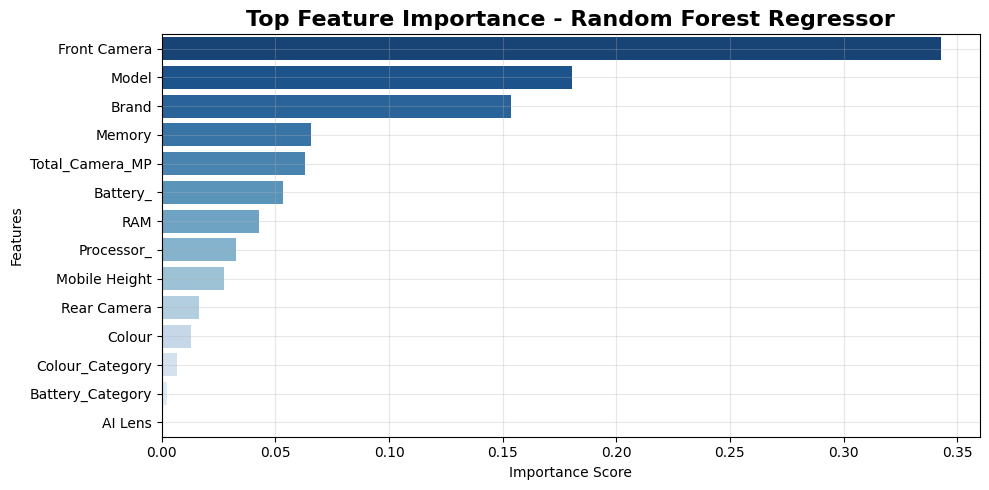

In [81]:
# 5.12 Feature Importance Analysis (Random Forest)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display feature importance table
display(feature_importance)

# Plot Feature Importance
plt.figure(figsize=(10,5))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature',
    palette='Blues_r'
)

plt.title(
    'Top Feature Importance - Random Forest Regressor',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

Observation 

The Random Forest model ranked all smartphone features according to their contribution to price prediction. The results indicate that Front Camera (34.29%) is the most influential feature, followed by Model (18.03%) and Brand (15.36%). Features such as Memory, Total Camera MP, Battery Capacity, RAM, and Processor also contribute to price prediction, while AI Lens, Battery Category, and Colour Category have minimal influence.

Interpretation 

The Feature Importance Analysis demonstrates that smartphone price is influenced by multiple technical and brand-related specifications rather than a single feature. Camera specifications, particularly the Front Camera, together with Brand and Model, play a dominant role in determining smartphone prices. Hardware specifications such as Memory, Battery Capacity, RAM, and Processor also contribute significantly, whereas cosmetic features like Colour and AI Lens have little impact on pricing decisions.

Key Insights 

- Front Camera is the most influential feature for predicting smartphone prices.
- Brand and Model significantly affect smartphone pricing due to market reputation and product positioning.
- Memory, Battery Capacity, RAM, and Processor are important hardware specifications influencing price.
- Total Camera MP also contributes to price prediction, highlighting the importance of camera quality.
- Colour, Battery Category, and AI Lens have very low importance, indicating they contribute minimally to price estimation.
- Random Forest successfully identifies the relative importance of each feature, making the model highly interpretable.

Business Impact 

The Feature Importance Analysis provides valuable insights for smartphone manufacturers and retailers. Companies should focus on improving camera quality, memory capacity, battery performance, and processor efficiency, as these features have the greatest influence on product pricing. Marketing campaigns should emphasize these high-impact specifications rather than cosmetic features such as colour or AI lens, enabling more effective pricing strategies and better alignment with customer preferences.

The Feature Importance Analysis identified the smartphone specifications that contribute most significantly to price prediction. Based on these findings, the next section presents practical business recommendations that organizations can use to improve pricing strategies, product development, and marketing decisions.

### 5.13 Business Recommendations


#### 1. Focus on High-Impact Features
The analysis shows that Front Camera, Brand, Model, Memory, Battery Capacity, RAM, and Processor have the greatest influence on smartphone prices. Companies should prioritize improving these features when designing premium smartphone models.

#### 2. Optimize Pricing Strategy
Machine learning models can be used to estimate the market value of new smartphones before launch. This enables organizations to set competitive prices based on product specifications rather than relying solely on market assumptions.

#### 3. Strengthen Brand Positioning
Brand emerged as one of the most influential pricing factors. Companies should invest in brand reputation, customer satisfaction, and product quality to justify premium pricing.

#### 4. Improve Marketing Campaigns
Marketing efforts should highlight specifications that customers value most, such as camera quality, memory, processor performance, and battery capacity. Less emphasis should be placed on low-impact features such as colour variations or AI lens.

#### 5. Better Product Portfolio Planning
Manufacturers can use feature importance analysis to identify which specifications provide maximum value to customers, helping optimize product configurations across budget, mid-range, and flagship smartphone categories.

#### 6. Data-Driven Business Decisions
Organizations should integrate predictive machine learning models into pricing and product planning processes. This reduces pricing errors, improves profitability, and enables faster decision-making based on real market data.

### Interpretation

The developed machine learning models demonstrate that smartphone pricing is primarily driven by hardware specifications and brand value. Organizations can leverage these insights to make evidence-based pricing decisions, optimize product development, and improve overall market competitiveness.

### Key Business Insights

• Front Camera is the strongest predictor of smartphone price.

• Brand reputation significantly influences product pricing.

• Memory, Battery Capacity, RAM, and Processor remain key hardware specifications affecting price.

• Machine learning enables more consistent and data-driven pricing decisions.

• Random Forest provides the most reliable predictions for smartphone price estimation in this project.

• Businesses can use these insights to improve profitability, product positioning, and customer satisfaction.

### Business Value

Implementing this predictive pricing framework enables organizations to:

• Launch products with competitive and data-driven pricing.

• Reduce manual pricing errors.

• Improve customer confidence through fair pricing.

• Enhance inventory planning by understanding feature demand.

• Support strategic decision-making using machine learning insights.

Overall, this approach helps organizations improve operational efficiency while maintaining competitiveness in the rapidly evolving smartphone market.

The business recommendations demonstrate how the findings of this project can support real-world pricing decisions. The final section summarizes the complete project, highlights the major achievements, and presents the overall conclusion of the smartphone price prediction system.

## 5.14 Final Project Conclusion

Purpose 

This section summarizes the overall project, highlights the major findings, evaluates the developed machine learning models, and presents the final conclusion based on the analysis and prediction results.

### Project Summary 

This project successfully developed a machine learning-based smartphone price prediction system using various smartphone specifications as input features. The workflow included data exploration, preprocessing, feature engineering, feature selection, model development, model evaluation, feature importance analysis, and business recommendations.

Two machine learning algorithms—Linear Regression and Random Forest Regression—were implemented and compared to identify the most effective model for predicting smartphone prices.

### Final Conclusion 

The results demonstrate that machine learning can effectively estimate smartphone prices using product specifications. Among the evaluated models, the Random Forest Regressor outperformed Linear Regression by achieving lower prediction errors and a higher R² Score, making it the most suitable model for this dataset.

Feature Importance Analysis further revealed that Front Camera, Model, Brand, Memory, Battery Capacity, RAM, and Processor are the primary factors influencing smartphone prices, whereas features such as AI Lens and Colour Category contribute relatively little to price prediction.

Overall, the developed predictive model provides a reliable, data-driven approach for estimating smartphone prices and supports informed business decision-making in the highly competitive smartphone market.

### Major Achievements 

✔ Successfully explored and cleaned the smartphone dataset.

✔ Performed feature engineering to create meaningful variables.

✔ Selected the most relevant features for price prediction.

✔ Built and evaluated multiple machine learning models.

✔ Compared model performance using MAE, MSE, RMSE, and R² Score.

✔ Identified the most influential smartphone features through Feature Importance Analysis.

✔ Generated business recommendations based on analytical findings.

✔ Developed a complete end-to-end machine learning workflow for smartphone price prediction.

### Future Scope 

The performance of the prediction system can be further improved by:

• Collecting a larger and more diverse smartphone dataset.

• Including additional features such as display quality, refresh rate, charging speed, operating system, network technology, and customer ratings.

• Applying advanced machine learning techniques such as Gradient Boosting, XGBoost, LightGBM, or CatBoost.

• Performing hyperparameter tuning to optimize model performance.

• Deploying the trained model as a web application for real-time smartphone price prediction.

### Final Key Takeaways 

• Random Forest Regression was the best-performing model in this project.

• Smartphone prices are primarily influenced by hardware specifications and brand value.

• Data preprocessing and feature engineering significantly improved model quality.

• Feature Importance Analysis enhanced the interpretability of the machine learning model.

• Machine learning provides an efficient and scalable solution for smartphone price estimation.

• The developed solution can support pricing strategies, product planning, and business decision-making in the smartphone industry.

### Closing Statement 

This project successfully demonstrates the practical application of Data Analytics and Machine Learning in solving a real-world business problem. By combining data preprocessing, feature engineering, predictive modeling, performance evaluation, and business insights, the project delivers a complete analytical solution for smartphone price prediction. The findings can assist organizations in making data-driven pricing decisions, improving product strategies, and enhancing overall business performance.

##  6. References

• Scikit-learn Documentation
https://scikit-learn.org/

• Pandas Documentation
https://pandas.pydata.org/

• NumPy Documentation
https://numpy.org/

• Matplotlib Documentation
https://matplotlib.org/

• Seaborn Documentation
https://seaborn.pydata.org/